
# Working with XES Event Logs in Python

**This notebook is part of the Process Intelligence in Action (2AMI30) course**

This notebook is a hands-on introduction to the **XES (.xes) event log format**, which is widely used in **process mining**.  
You are expected to be comfortable with Python, pandas, and Jupyter notebooks.

This notebook will cover:
- Understanding the structure of an XES file (log → trace → event)
- Loading and inspecting XES files in Python
- Converting XES logs to pandas DataFrames
- Performing basic exploratory analysis on event logs

We will use the `pm4py` library, the de‑facto standard for process mining in Python.



## 1. Understanding the structure of an XES file

The **eXtensible Event Stream (XES)** format is an XML-based standard for event logs.

Conceptually, an XES log has three nested levels:

1. **Log** – the whole dataset
2. **Trace** – one process instance
3. **Event** – one step in the process

Each level can have **attributes**:
- Events typically have: `concept:name`, `time:timestamp`, `org:resource`
- Traces often have: `case_id`, `customer`, `variant`

Think of a trace as a sequence of time-ordered events describing *what happened* for a single case.



## 2. Required libraries

We use **pm4py** for reading and analyzing XES logs.

If pm4py is not installed, run the following (once):
```bash
pip install pm4py
```


In [1]:

import pm4py
import pandas as pd

from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.conversion.log import converter as log_converter



## 3. Loading an XES file

Place your `.xes` file in the same directory as this notebook, or update the path below.


In [2]:
xes_path = "Supermarket_Cashier.xes"
xes_path2 = "Supermarket_Clerk.xes"
xes_path3 = "Supermarket_Counter.xes"
xes_path4 = "Supermarket_Customer.xes"
xes_path5 = "Supermarket_Manager.xes"

log_cashier = xes_importer.apply(xes_path)
log_clerk = xes_importer.apply(xes_path2)
log_counter = xes_importer.apply(xes_path3)
log_customer = xes_importer.apply(xes_path4)
log_manager = xes_importer.apply(xes_path5)

d:\TUE Study Material\Q2\Advanced Process Mining\Assignment\Phase3\course-applied-processmining\.venv\lib\site-packages\pm4py\util\dt_parsing\parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/37 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/10 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/18 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/9557 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]


## 6. Converting an XES log to a pandas DataFrame

For data science workflows, it is often convenient to work with a **tabular representation**.

pm4py provides a built-in conversion.


In [3]:

log_df_cashier = log_converter.apply(log_cashier, variant=log_converter.Variants.TO_DATA_FRAME)

log_df_cashier.head(10)


,hr,lifecycle:transition,concept:name,d,day,time:timestamp,col,q,iMI,mC,mI,iMC,cid,cnt,x,pc,case:concept:name
0,16.0,complete,Start Shift,4.0,0.0,2026-01-26 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
1,NaN,complete,Open counter,4.0,NaN,2026-01-26 16:00:00+00:00,"[(0,0,0,true),(1,1,19,true),(2,0,0,true),(3,0,...","[7,8,9,10,11,12,13,14,15,16,17]",0.0,0.0,0.0,0.0,6.0,NaN,NaN,NaN,10
2,NaN,complete,Close counter,4.0,NaN,2026-01-26 20:00:00+00:00,"[(0,2,92,true),(1,0,0,false),(2,1,5,true),(3,2...","[4,5,1,12,13,14,15,16,17]",7.0,0.0,0.0,9.0,6.0,17.0,40.0,NaN,10
3,NaN,complete,End shift,NaN,NaN,2026-01-26 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,10
4,16.0,complete,Start Shift,4.0,1.0,2026-01-27 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
5,NaN,complete,Open counter,4.0,NaN,2026-01-27 16:00:00+00:00,"[(0,2,29,true),(1,1,52,true),(2,1,27,true),(3,...","[9,10,11,12,13,14,15,16,17]",4.0,0.0,0.0,4.0,8.0,NaN,NaN,NaN,10
6,NaN,complete,Close counter,4.0,NaN,2026-01-27 20:00:00+00:00,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[15,16,17,0,5,1,4,2,3,9,6]",10.0,1.0,0.0,8.0,8.0,21.0,40.0,NaN,10
7,NaN,complete,End shift,NaN,NaN,2026-01-27 20:01:49.936000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,0.0,10
8,16.0,complete,Start Shift,4.0,2.0,2026-01-28 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
9,NaN,complete,Open counter,4.0,NaN,2026-01-28 16:00:00+00:00,"[(0,1,60,true),(1,2,70,true),(2,0,0,true),(3,0...","[9,10,11,12,13,14,15,16,17]",2.0,0.0,0.0,2.0,8.0,NaN,NaN,NaN,10


In [4]:
log_df_clerk = log_converter.apply(log_clerk, variant=log_converter.Variants.TO_DATA_FRAME)

log_df_clerk.head(10)

,id,lifecycle:transition,concept:name,time:timestamp,cid,q,pc,i,x,case:concept:name
0,NaN,complete,Cleanup abandoned item,2026-01-26 14:19:35.784000+00:00,NaN,NaN,NaN,NaN,10.0,100
1,5.0,complete,Start Price Check,2026-01-26 14:21:39.068000+00:00,0.0,NaN,NaN,NaN,NaN,100
2,5.0,complete,End price check,2026-01-26 14:21:57.123000+00:00,0.0,"[3,11,12]",1.0,147.0,NaN,100
3,NaN,complete,Cleanup abandoned item,2026-01-26 14:25:16.881000+00:00,NaN,NaN,NaN,NaN,56.0,100
4,NaN,complete,Cleanup abandoned item,2026-01-26 14:27:41.845000+00:00,NaN,NaN,NaN,NaN,57.0,100
5,NaN,complete,Cleanup abandoned item,2026-01-26 14:45:20.630000+00:00,NaN,NaN,NaN,NaN,61.0,100
6,NaN,complete,Cleanup abandoned item,2026-01-26 14:46:28.549000+00:00,NaN,NaN,NaN,NaN,46.0,100
7,NaN,complete,Cleanup abandoned item,2026-01-26 14:50:19.240000+00:00,NaN,NaN,NaN,NaN,24.0,100
8,NaN,complete,Cleanup abandoned item,2026-01-26 15:00:03.624000+00:00,NaN,NaN,NaN,NaN,4.0,100
9,36.0,complete,Start Price Check,2026-01-26 15:04:48.170000+00:00,4.0,NaN,NaN,NaN,NaN,100


In [5]:
log_df_counter = log_converter.apply(log_counter, variant=log_converter.Variants.TO_DATA_FRAME)
log_df_counter.head(10)

,col,q,concept:name,iMI,d,mC,caid,lifecycle:transition,mI,time:timestamp,...,p,s,pc,id,items,b,clid,cnt,x,case:concept:name
0,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,-1.0,4.0,0.0,2.0,complete,0.0,2026-01-26 14:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,"[(0,0,0,true),(1,0,0,false),(2,0,0,false),(3,0...",[],Enter Queue,0.0,NaN,0.0,NaN,complete,0.0,2026-01-26 14:03:27.627000+00:00,...,Pin,lItem,0.0,0.0,58.0,NaN,NaN,NaN,NaN,0
2,"[(0,1,58,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,58.0,2026-01-26 14:03:30.466000+00:00,...,Pin,lItem,0.0,0.0,58.0,False,NaN,NaN,NaN,0
3,"[(0,1,57,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,57.0,2026-01-26 14:03:34.164000+00:00,...,Pin,lItem,0.0,0.0,57.0,True,NaN,NaN,NaN,0
4,"[(0,1,56,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,56.0,2026-01-26 14:03:37.690000+00:00,...,Pin,lItem,1.0,0.0,56.0,False,NaN,NaN,NaN,0
5,NaN,NaN,Start Price Check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:37.690000+00:00,...,NaN,NaN,NaN,0.0,NaN,NaN,105.0,NaN,NaN,0
6,"[(0,1,55,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,55.0,2026-01-26 14:03:40.586000+00:00,...,Pin,lItem,1.0,0.0,55.0,False,NaN,NaN,NaN,0
7,"[(0,1,54,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,54.0,2026-01-26 14:03:42.967000+00:00,...,Pin,lItem,1.0,0.0,54.0,False,NaN,NaN,NaN,0
8,NaN,[],End price check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:44.083000+00:00,...,NaN,NaN,1.0,0.0,NaN,NaN,105.0,NaN,NaN,0
9,"[(0,1,53,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,53.0,2026-01-26 14:03:45.388000+00:00,...,Pin,lItem,0.0,0.0,53.0,False,NaN,NaN,NaN,0


In [6]:
# Rows where case:concept:name changes
changed_rows = log_df_counter[
    log_df_counter['case:concept:name']
    != log_df_counter['case:concept:name'].shift()
]

# First 10 such rows
changed_rows.head(30)

,col,q,concept:name,iMI,d,mC,caid,lifecycle:transition,mI,time:timestamp,...,p,s,pc,id,items,b,clid,cnt,x,case:concept:name
0,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,-1.0,4.0,0.0,2.0,complete,0.0,2026-01-26 14:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
153860,"[(0,4,41,true),(1,0,0,false),(2,0,0,false),(3,...","[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,0.0,4.0,4.0,4.0,complete,41.0,2026-01-26 15:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
235987,"[(0,0,0,true),(1,1,0,true),(2,1,39,true),(3,1,...","[11,12,13,14,15,16,17]",Open counter,0.0,3.0,0.0,19.0,complete,0.0,2026-01-26 17:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
305038,"[(0,1,28,true),(1,1,19,true),(2,2,54,true),(3,...","[12,13,14,15,16,17]",Open counter,3.0,4.0,0.0,62.0,complete,0.0,2026-01-26 18:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11
382685,"[(0,1,50,false),(1,0,0,true),(2,0,0,true),(3,0...","[13,14,15,16,17,0]",Open counter,1.0,4.0,0.0,13.0,complete,0.0,2026-01-27 18:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
430108,"[(0,0,0,false),(1,0,0,false),(2,2,49,false),(3...","[14,15,16,17,0,5,1,4,2,3]",Open counter,6.0,3.0,0.0,22.0,complete,0.0,2026-01-27 19:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13
475221,"[(0,0,0,false),(1,0,0,false),(2,2,49,false),(3...","[15,16,17,0,5,1,4,2,3]",Open counter,6.0,3.0,0.0,21.0,complete,0.0,2026-01-27 19:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
502159,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[16,17,0,5,1,4,2,3,9,6,8,7]",Open counter,10.0,2.0,1.0,5.0,complete,0.0,2026-01-27 20:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15
525312,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[17,0,5,1,4,2,3,9,6,8,7]",Open counter,10.0,2.0,1.0,3.0,complete,0.0,2026-01-27 20:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16
543209,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[0,5,1,4,2,3,9,6,8,7]",Open counter,10.0,2.0,1.0,6.0,complete,0.0,2026-01-27 20:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17


In [7]:
print(log_df_counter['s'].unique())

[nan 'lItem' 'lRandom' 'lCust']


In [8]:
log_df_customer = log_converter.apply(log_customer, variant=log_converter.Variants.TO_DATA_FRAME)

log_df_customer.head(50)

,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp,p,col,...,i,q,pc,mC,mI,iMC,cid,b,clid,case:concept:name
0,lItem,Enter store,0.0,28.0,0.0,complete,58.0,2026-01-26 14:00:00+00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,lItem,Pickup Item,NaN,0.0,NaN,complete,58.0,2026-01-26 14:00:00+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,lItem,Pickup Item,NaN,1.0,NaN,complete,58.0,2026-01-26 14:00:03.547000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,lItem,Pickup Item,NaN,2.0,NaN,complete,58.0,2026-01-26 14:00:06.578000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,lItem,Pickup Item,NaN,3.0,NaN,complete,58.0,2026-01-26 14:00:09.296000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,lItem,Pickup Item,NaN,4.0,NaN,complete,58.0,2026-01-26 14:00:11.957000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,lItem,Pickup Item,NaN,5.0,NaN,complete,58.0,2026-01-26 14:00:14.419000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,lItem,Pickup Item,NaN,6.0,NaN,complete,58.0,2026-01-26 14:00:17.540000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
8,lItem,Pickup Item,NaN,7.0,NaN,complete,58.0,2026-01-26 14:00:21.145000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9,lItem,Pickup Item,NaN,8.0,NaN,complete,58.0,2026-01-26 14:00:25.491000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [9]:
log_df_customer['cid'].unique()

array([nan,  0.,  7.,  3.,  1.,  6.,  8.,  2.,  5.,  4., 12., 11.,  9.,
       10., 13., 14., 17., 15., 16.])

In [10]:
log_df_manager = log_converter.apply(log_manager, variant=log_converter.Variants.TO_DATA_FRAME)

log_df_manager.head(10)

,lifecycle:transition,concept:name,time:timestamp,pO,case:concept:name
0,complete,Start Shift,2026-01-27 14:00:00+00:00,1,201
1,complete,End Shift,2026-01-27 22:08:06.956000+00:00,1,201
2,complete,Start Shift,2026-01-28 14:00:00+00:00,1,201
3,complete,End Shift,2026-01-28 22:07:51.574000+00:00,1,201
4,complete,Start Shift,2026-01-30 14:00:00+00:00,1,201
5,complete,End Shift,2026-01-30 22:07:41.746000+00:00,1,201
6,complete,Start Shift,2026-01-31 14:00:00+00:00,1,201
7,complete,End Shift,2026-01-31 22:04:07.956000+00:00,1,201
8,complete,Start Shift,2026-02-03 14:00:00+00:00,1,201
9,complete,End Shift,2026-02-03 22:02:46.851000+00:00,1,201



### Interpreting the DataFrame

Typical columns:
- `case:concept:name` → case ID
- `concept:name` → activity
- `time:timestamp` → event time

Each row corresponds to **one event**.
Multiple rows with the same case ID form a trace.



## 8. Event ordering and timestamps

Event order **must always be derived from timestamps**, not row order.


In [11]:

# Ensure correct ordering
log_df_cashier_sorted = log_df_cashier.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_cashier_sorted.head(10)


,hr,lifecycle:transition,concept:name,d,day,time:timestamp,col,q,iMI,mC,mI,iMC,cid,cnt,x,pc,case:concept:name
0,16.0,complete,Start Shift,4.0,0.0,2026-01-26 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
1,NaN,complete,Open counter,4.0,NaN,2026-01-26 16:00:00+00:00,"[(0,0,0,true),(1,1,19,true),(2,0,0,true),(3,0,...","[7,8,9,10,11,12,13,14,15,16,17]",0.0,0.0,0.0,0.0,6.0,NaN,NaN,NaN,10
2,NaN,complete,Close counter,4.0,NaN,2026-01-26 20:00:00+00:00,"[(0,2,92,true),(1,0,0,false),(2,1,5,true),(3,2...","[4,5,1,12,13,14,15,16,17]",7.0,0.0,0.0,9.0,6.0,17.0,40.0,NaN,10
3,NaN,complete,End shift,NaN,NaN,2026-01-26 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,10
4,16.0,complete,Start Shift,4.0,1.0,2026-01-27 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
5,NaN,complete,Open counter,4.0,NaN,2026-01-27 16:00:00+00:00,"[(0,2,29,true),(1,1,52,true),(2,1,27,true),(3,...","[9,10,11,12,13,14,15,16,17]",4.0,0.0,0.0,4.0,8.0,NaN,NaN,NaN,10
6,NaN,complete,Close counter,4.0,NaN,2026-01-27 20:00:00+00:00,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[15,16,17,0,5,1,4,2,3,9,6]",10.0,1.0,0.0,8.0,8.0,21.0,40.0,NaN,10
7,NaN,complete,End shift,NaN,NaN,2026-01-27 20:01:49.936000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,0.0,10
8,16.0,complete,Start Shift,4.0,2.0,2026-01-28 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
9,NaN,complete,Open counter,4.0,NaN,2026-01-28 16:00:00+00:00,"[(0,1,60,true),(1,2,70,true),(2,0,0,true),(3,0...","[9,10,11,12,13,14,15,16,17]",2.0,0.0,0.0,2.0,8.0,NaN,NaN,NaN,10


In [12]:
# Ensure correct ordering
log_df_clerk_sorted = log_df_clerk.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_clerk_sorted.head(10)

,id,lifecycle:transition,concept:name,time:timestamp,cid,q,pc,i,x,case:concept:name
0,NaN,complete,Cleanup abandoned item,2026-01-26 14:19:35.784000+00:00,NaN,NaN,NaN,NaN,10.0,100
1,5.0,complete,Start Price Check,2026-01-26 14:21:39.068000+00:00,0.0,NaN,NaN,NaN,NaN,100
2,5.0,complete,End price check,2026-01-26 14:21:57.123000+00:00,0.0,"[3,11,12]",1.0,147.0,NaN,100
3,NaN,complete,Cleanup abandoned item,2026-01-26 14:25:16.881000+00:00,NaN,NaN,NaN,NaN,56.0,100
4,NaN,complete,Cleanup abandoned item,2026-01-26 14:27:41.845000+00:00,NaN,NaN,NaN,NaN,57.0,100
5,NaN,complete,Cleanup abandoned item,2026-01-26 14:45:20.630000+00:00,NaN,NaN,NaN,NaN,61.0,100
6,NaN,complete,Cleanup abandoned item,2026-01-26 14:46:28.549000+00:00,NaN,NaN,NaN,NaN,46.0,100
7,NaN,complete,Cleanup abandoned item,2026-01-26 14:50:19.240000+00:00,NaN,NaN,NaN,NaN,24.0,100
8,NaN,complete,Cleanup abandoned item,2026-01-26 15:00:03.624000+00:00,NaN,NaN,NaN,NaN,4.0,100
9,36.0,complete,Start Price Check,2026-01-26 15:04:48.170000+00:00,4.0,NaN,NaN,NaN,NaN,100


In [13]:
# Ensure correct ordering
log_df_counter_sorted = log_df_counter.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_counter_sorted.head(10)

,col,q,concept:name,iMI,d,mC,caid,lifecycle:transition,mI,time:timestamp,...,p,s,pc,id,items,b,clid,cnt,x,case:concept:name
0,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,-1.0,4.0,0.0,2.0,complete,0.0,2026-01-26 14:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,"[(0,0,0,true),(1,0,0,false),(2,0,0,false),(3,0...",[],Enter Queue,0.0,NaN,0.0,NaN,complete,0.0,2026-01-26 14:03:27.627000+00:00,...,Pin,lItem,0.0,0.0,58.0,NaN,NaN,NaN,NaN,0
2,"[(0,1,58,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,58.0,2026-01-26 14:03:30.466000+00:00,...,Pin,lItem,0.0,0.0,58.0,False,NaN,NaN,NaN,0
3,"[(0,1,57,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,57.0,2026-01-26 14:03:34.164000+00:00,...,Pin,lItem,0.0,0.0,57.0,True,NaN,NaN,NaN,0
4,"[(0,1,56,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,56.0,2026-01-26 14:03:37.690000+00:00,...,Pin,lItem,1.0,0.0,56.0,False,NaN,NaN,NaN,0
5,NaN,NaN,Start Price Check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:37.690000+00:00,...,NaN,NaN,NaN,0.0,NaN,NaN,105.0,NaN,NaN,0
6,"[(0,1,55,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,55.0,2026-01-26 14:03:40.586000+00:00,...,Pin,lItem,1.0,0.0,55.0,False,NaN,NaN,NaN,0
7,"[(0,1,54,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,54.0,2026-01-26 14:03:42.967000+00:00,...,Pin,lItem,1.0,0.0,54.0,False,NaN,NaN,NaN,0
8,NaN,[],End price check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:44.083000+00:00,...,NaN,NaN,1.0,0.0,NaN,NaN,105.0,NaN,NaN,0
9,"[(0,1,53,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,53.0,2026-01-26 14:03:45.388000+00:00,...,Pin,lItem,0.0,0.0,53.0,False,NaN,NaN,NaN,0


In [14]:
# Ensure correct ordering
log_df_customer_sorted = log_df_customer.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_customer_sorted.head(10)

,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp,p,col,...,i,q,pc,mC,mI,iMC,cid,b,clid,case:concept:name
0,lItem,Enter store,0.0,28.0,0.0,complete,58.0,2026-01-26 14:00:00+00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,lItem,Pickup Item,NaN,0.0,NaN,complete,58.0,2026-01-26 14:00:00+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,lItem,Pickup Item,NaN,1.0,NaN,complete,58.0,2026-01-26 14:00:03.547000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,lItem,Pickup Item,NaN,2.0,NaN,complete,58.0,2026-01-26 14:00:06.578000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,lItem,Pickup Item,NaN,3.0,NaN,complete,58.0,2026-01-26 14:00:09.296000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,lItem,Pickup Item,NaN,4.0,NaN,complete,58.0,2026-01-26 14:00:11.957000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,lItem,Pickup Item,NaN,5.0,NaN,complete,58.0,2026-01-26 14:00:14.419000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,lItem,Pickup Item,NaN,6.0,NaN,complete,58.0,2026-01-26 14:00:17.540000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
8,lItem,Pickup Item,NaN,7.0,NaN,complete,58.0,2026-01-26 14:00:21.145000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9,lItem,Pickup Item,NaN,8.0,NaN,complete,58.0,2026-01-26 14:00:25.491000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [15]:
# Ensure correct ordering
log_df_manager_sorted = log_df_manager.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_manager_sorted.head(70)

,lifecycle:transition,concept:name,time:timestamp,pO,case:concept:name
0,complete,Start Shift,2026-01-27 14:00:00+00:00,1,201
1,complete,End Shift,2026-01-27 22:08:06.956000+00:00,1,201
2,complete,Start Shift,2026-01-28 14:00:00+00:00,1,201
3,complete,End Shift,2026-01-28 22:07:51.574000+00:00,1,201
4,complete,Start Shift,2026-01-30 14:00:00+00:00,1,201
...,...,...,...,...,...
65,complete,End Shift,2026-02-19 22:03:12.422000+00:00,0,202
66,complete,Start Shift,2026-02-20 14:00:00+00:00,0,202
67,complete,End Shift,2026-02-20 22:00:00+00:00,0,202
68,complete,Start Shift,2026-02-23 14:00:00+00:00,0,202


## 12. Temporal analysis: arrivals over time

Event logs often exhibit strong temporal patterns:

- business hours
- daily/weekly seasonality
- batching effects

**Temporal analysis wrt to events happening across along five logs followed by a case wise analysis as well for cross checking.**


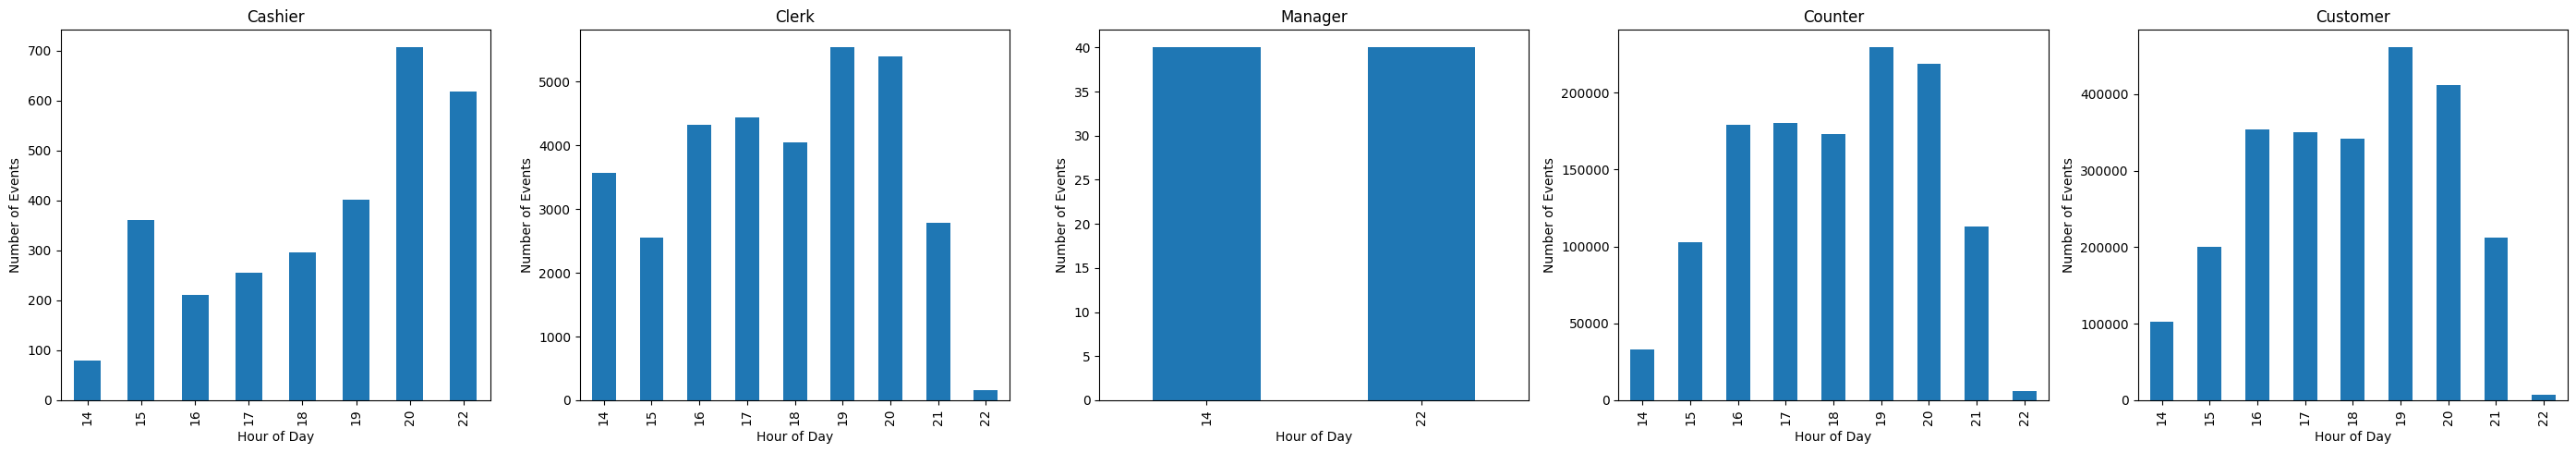

In [14]:
import matplotlib.pyplot as plt

# Add hour column to each log
log_df_cashier['hour'] = log_df_cashier['time:timestamp'].dt.hour
log_df_clerk['hour'] = log_df_clerk['time:timestamp'].dt.hour
log_df_manager['hour'] = log_df_manager['time:timestamp'].dt.hour
log_df_counter['hour'] = log_df_counter['time:timestamp'].dt.hour
log_df_customer['hour'] = log_df_customer['time:timestamp'].dt.hour

# Hourly arrivals/events
cashier_hourly = log_df_cashier.groupby('hour').size()
clerk_hourly = log_df_clerk.groupby('hour').size()
manager_hourly = log_df_manager.groupby('hour').size()
counter_hourly = log_df_counter.groupby('hour').size()
customer_hourly = log_df_customer.groupby('hour').size()

# Create subplots
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

# Cashier
cashier_hourly.plot(kind='bar', ax=axes[0])
axes[0].set_title("Cashier")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Events")

# Clerk
clerk_hourly.plot(kind='bar', ax=axes[1])
axes[1].set_title("Clerk")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Number of Events")

# Manager
manager_hourly.plot(kind='bar', ax=axes[2])
axes[2].set_title("Manager")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Number of Events")

# Counter
counter_hourly.plot(kind='bar', ax=axes[3])
axes[3].set_title("Counter")
axes[3].set_xlabel("Hour of Day")
axes[3].set_ylabel("Number of Events")

# Customer
customer_hourly.plot(kind='bar', ax=axes[4])
axes[4].set_title("Customer")
axes[4].set_xlabel("Hour of Day")
axes[4].set_ylabel("Number of Events")

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

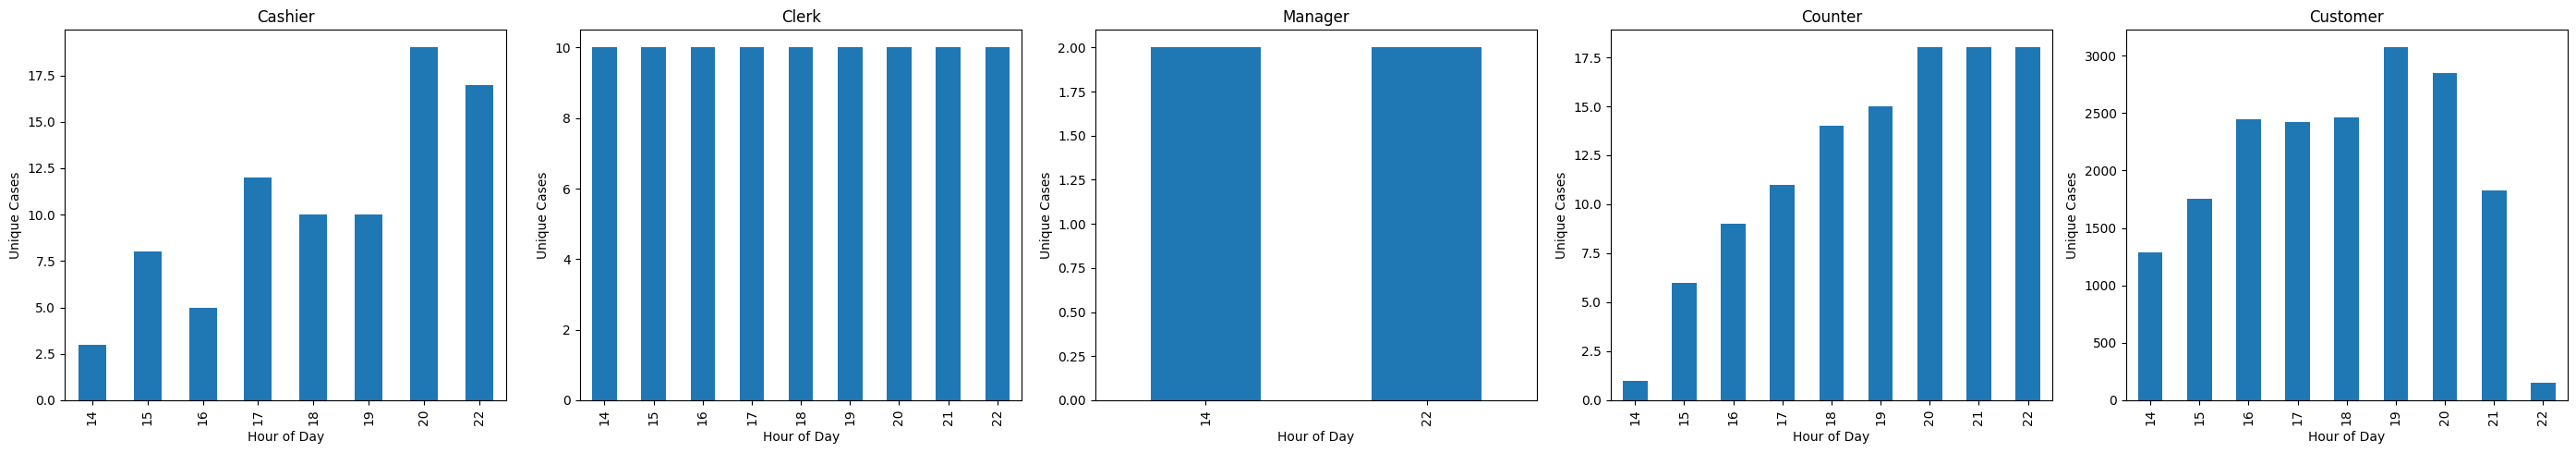

In [50]:
#cross checking with cases
import matplotlib.pyplot as plt

# Add hour column to each log
log_df_cashier['hour'] = (
    log_df_cashier['time:timestamp'].dt.hour
)

log_df_clerk['hour'] = (
    log_df_clerk['time:timestamp'].dt.hour
)

log_df_manager['hour'] = (
    log_df_manager['time:timestamp'].dt.hour
)

log_df_counter['hour'] = (
    log_df_counter['time:timestamp'].dt.hour
)

log_df_customer['hour'] = (
    log_df_customer['time:timestamp'].dt.hour
)

# -----------------------------------------
# UNIQUE CASES PER HOUR
# -----------------------------------------

cashier_hourly = (
    log_df_cashier.groupby('hour')
    ['case:concept:name']
    .nunique()
)

clerk_hourly = (
    log_df_clerk.groupby('hour')
    ['case:concept:name']
    .nunique()
)

manager_hourly = (
    log_df_manager.groupby('hour')
    ['case:concept:name']
    .nunique()
)

counter_hourly = (
    log_df_counter.groupby('hour')
    ['case:concept:name']
    .nunique()
)

customer_hourly = (
    log_df_customer.groupby('hour')
    ['case:concept:name']
    .nunique()
)

# -----------------------------------------
# CREATE SUBPLOTS
# -----------------------------------------

fig, axes = plt.subplots(
    1, 5,
    figsize=(28,5)
)

# Cashier
cashier_hourly.plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title("Cashier")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Unique Cases")

# Clerk
clerk_hourly.plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Clerk")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Unique Cases")

# Manager
manager_hourly.plot(
    kind='bar',
    ax=axes[2]
)

axes[2].set_title("Manager")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Unique Cases")

# Counter
counter_hourly.plot(
    kind='bar',
    ax=axes[3]
)

axes[3].set_title("Counter")
axes[3].set_xlabel("Hour of Day")
axes[3].set_ylabel("Unique Cases")

# Customer
customer_hourly.plot(
    kind='bar',
    ax=axes[4]
)

axes[4].set_title("Customer")
axes[4].set_xlabel("Hour of Day")
axes[4].set_ylabel("Unique Cases")

# Layout
plt.tight_layout()

# Show plots
plt.show()

**1. More counters are open than required indicating Resource wastage**

**2. The inflow of customers at 17:00 is lesser than 16:00 but we go on to open more counters which does not make sense**



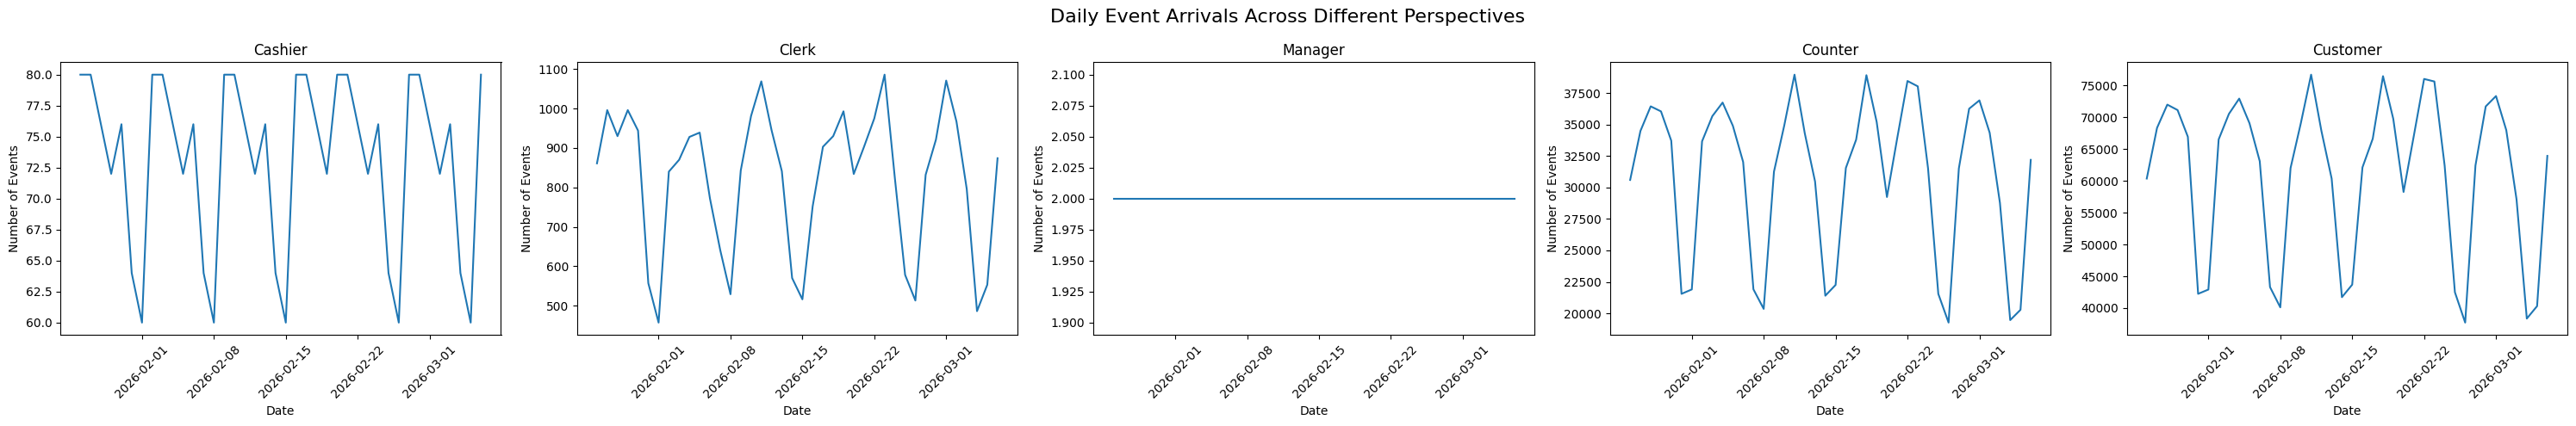

In [20]:

# Add date column to each log
log_df_cashier['date'] = log_df_cashier['time:timestamp'].dt.date
log_df_clerk['date'] = log_df_clerk['time:timestamp'].dt.date
log_df_manager['date'] = log_df_manager['time:timestamp'].dt.date
log_df_counter['date'] = log_df_counter['time:timestamp'].dt.date
log_df_customer['date'] = log_df_customer['time:timestamp'].dt.date

# Daily arrivals/events
cashier_daily = log_df_cashier.groupby('date').size()
clerk_daily = log_df_clerk.groupby('date').size()
manager_daily = log_df_manager.groupby('date').size()
counter_daily = log_df_counter.groupby('date').size()
customer_daily = log_df_customer.groupby('date').size()

# Create subplots
fig, axes = plt.subplots(1, 5, figsize=(30, 5))

# Cashier
cashier_daily.plot(ax=axes[0])
axes[0].set_title("Cashier")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Number of Events")
axes[0].tick_params(axis='x', rotation=45)

# Clerk
clerk_daily.plot(ax=axes[1])
axes[1].set_title("Clerk")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Number of Events")
axes[1].tick_params(axis='x', rotation=45)

# Manager
manager_daily.plot(ax=axes[2])
axes[2].set_title("Manager")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Number of Events")
axes[2].tick_params(axis='x', rotation=45)

# Counter
counter_daily.plot(ax=axes[3])
axes[3].set_title("Counter")
axes[3].set_xlabel("Date")
axes[3].set_ylabel("Number of Events")
axes[3].tick_params(axis='x', rotation=45)

# Customer
customer_daily.plot(ax=axes[4])
axes[4].set_title("Customer")
axes[4].set_xlabel("Date")
axes[4].set_ylabel("Number of Events")
axes[4].tick_params(axis='x', rotation=45)

# Main title
fig.suptitle("Daily Event Arrivals Across Different Perspectives", fontsize=16)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

**South (Zuid) Region: February 14 to February 22, 2026 more work due to spring break and carnival.For the South and Central regions, this holiday aligns precisely with Carnival 2026, which takes place from Sunday, February 15 through Tuesday, February 17, 2026. These exact dates align with festivities**

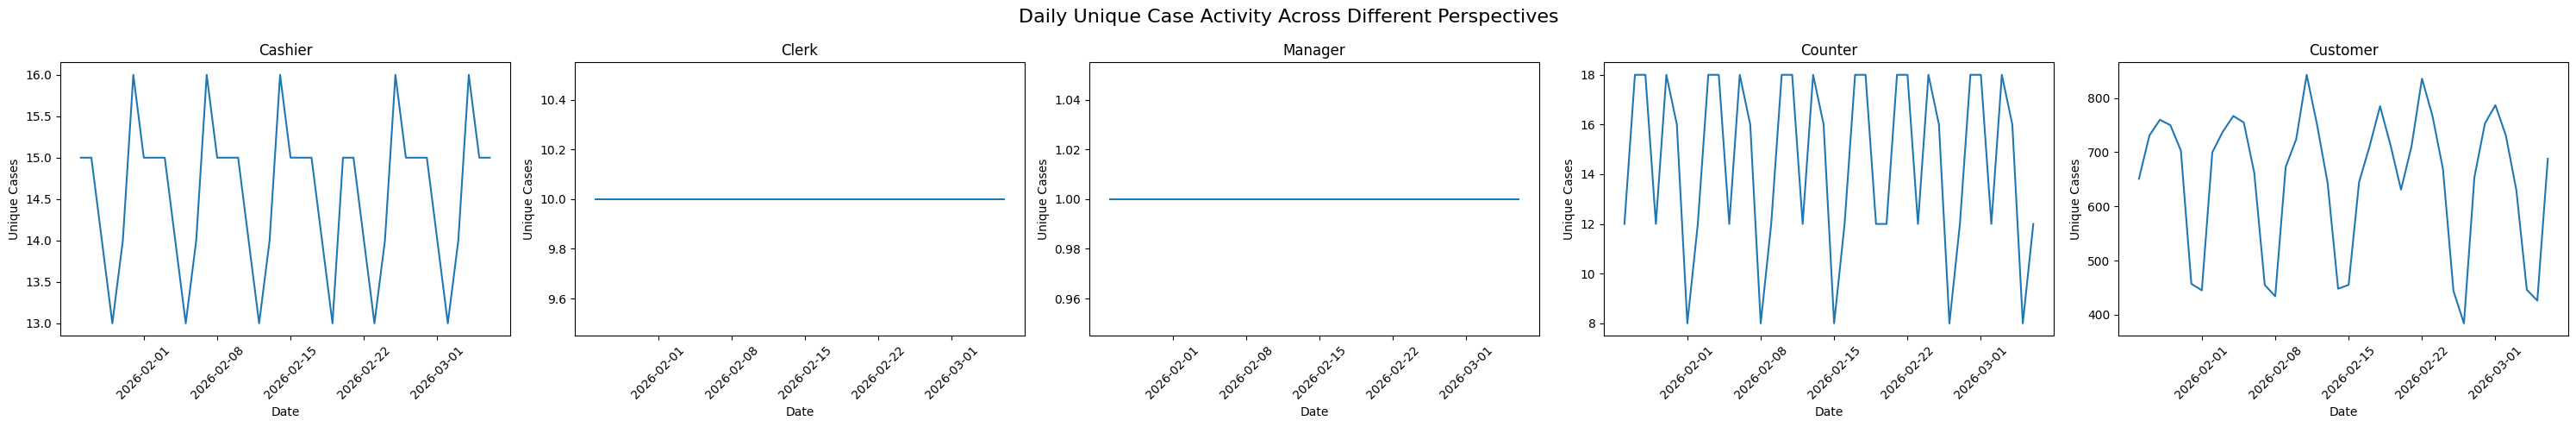

In [21]:
# Cross checking with cases
import matplotlib.pyplot as plt

# Add date column to each log
log_df_cashier['date'] = (
    log_df_cashier['time:timestamp'].dt.date
)

log_df_clerk['date'] = (
    log_df_clerk['time:timestamp'].dt.date
)

log_df_manager['date'] = (
    log_df_manager['time:timestamp'].dt.date
)

log_df_counter['date'] = (
    log_df_counter['time:timestamp'].dt.date
)

log_df_customer['date'] = (
    log_df_customer['time:timestamp'].dt.date
)

# ------------------------------------------------
# DAILY UNIQUE CASES
# ------------------------------------------------

cashier_daily = (
    log_df_cashier.groupby('date')
    ['case:concept:name']
    .nunique()
)

clerk_daily = (
    log_df_clerk.groupby('date')
    ['case:concept:name']
    .nunique()
)

manager_daily = (
    log_df_manager.groupby('date')
    ['case:concept:name']
    .nunique()
)

counter_daily = (
    log_df_counter.groupby('date')
    ['case:concept:name']
    .nunique()
)

customer_daily = (
    log_df_customer.groupby('date')
    ['case:concept:name']
    .nunique()
)

# ------------------------------------------------
# CREATE SUBPLOTS
# ------------------------------------------------

fig, axes = plt.subplots(
    1, 5,
    figsize=(30,5)
)

# Cashier
cashier_daily.plot(ax=axes[0])

axes[0].set_title("Cashier")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Unique Cases")

axes[0].tick_params(
    axis='x',
    rotation=45
)

# Clerk
clerk_daily.plot(ax=axes[1])

axes[1].set_title("Clerk")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Unique Cases")

axes[1].tick_params(
    axis='x',
    rotation=45
)

# Manager
manager_daily.plot(ax=axes[2])

axes[2].set_title("Manager")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Unique Cases")

axes[2].tick_params(
    axis='x',
    rotation=45
)

# Counter
counter_daily.plot(ax=axes[3])

axes[3].set_title("Counter")
axes[3].set_xlabel("Date")
axes[3].set_ylabel("Unique Cases")

axes[3].tick_params(
    axis='x',
    rotation=45
)

# Customer
customer_daily.plot(ax=axes[4])

axes[4].set_title("Customer")
axes[4].set_xlabel("Date")
axes[4].set_ylabel("Unique Cases")

axes[4].tick_params(
    axis='x',
    rotation=45
)

# Main title
fig.suptitle(
    "Daily Unique Case Activity Across Different Perspectives",
    fontsize=16
)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

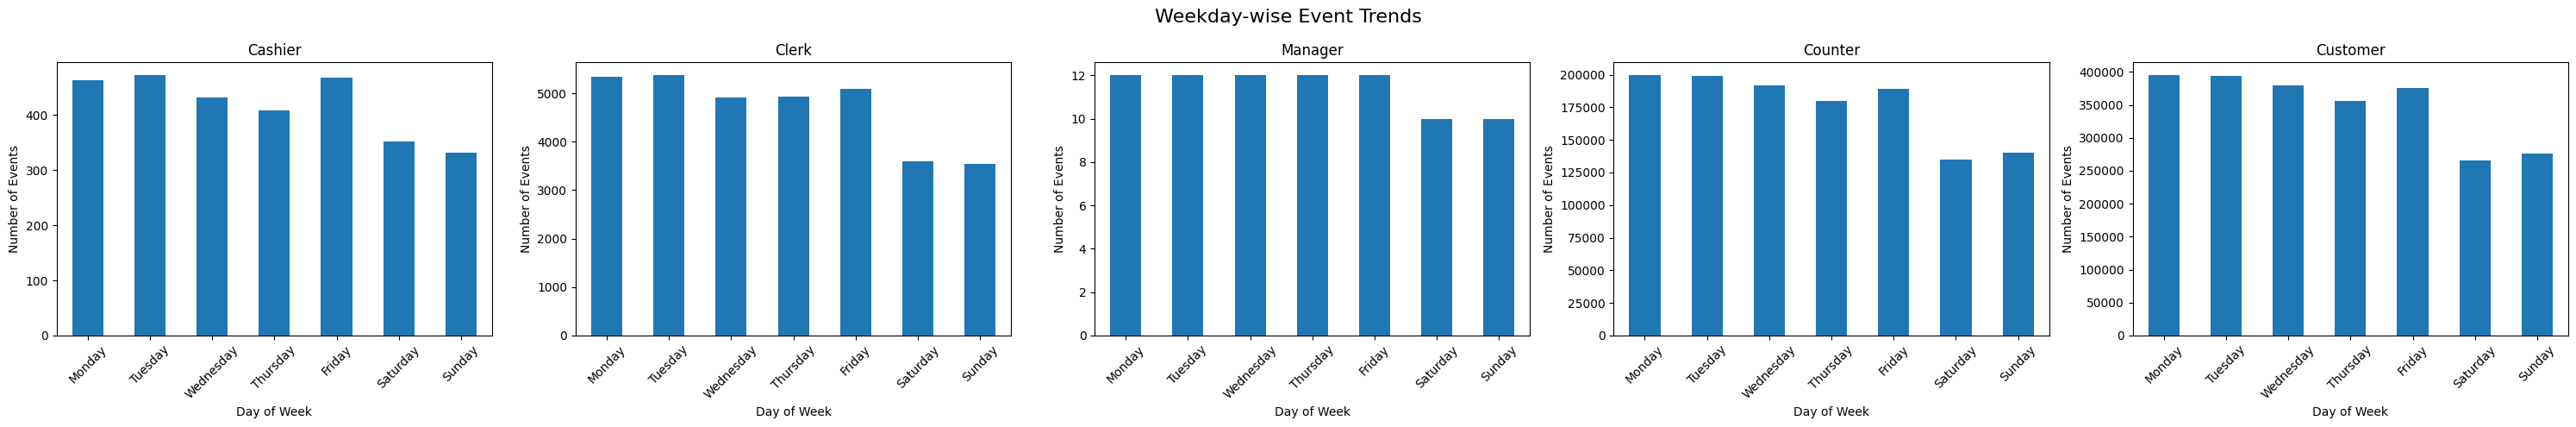

In [22]:


# Add weekday column to each log
log_df_cashier['weekday'] = log_df_cashier['time:timestamp'].dt.day_name()
log_df_clerk['weekday'] = log_df_clerk['time:timestamp'].dt.day_name()
log_df_manager['weekday'] = log_df_manager['time:timestamp'].dt.day_name()
log_df_counter['weekday'] = log_df_counter['time:timestamp'].dt.day_name()
log_df_customer['weekday'] = log_df_customer['time:timestamp'].dt.day_name()

# Define correct weekday order
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Count events by weekday and reorder
cashier_weekday = (
    log_df_cashier.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

clerk_weekday = (
    log_df_clerk.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

manager_weekday = (
    log_df_manager.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

counter_weekday = (
    log_df_counter.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

customer_weekday = (
    log_df_customer.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

# Create subplots
fig, axes = plt.subplots(1, 5, figsize=(30, 5))

# Cashier
cashier_weekday.plot(kind='bar', ax=axes[0])
axes[0].set_title("Cashier")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Events")
axes[0].tick_params(axis='x', rotation=45)

# Clerk
clerk_weekday.plot(kind='bar', ax=axes[1])
axes[1].set_title("Clerk")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Events")
axes[1].tick_params(axis='x', rotation=45)

# Manager
manager_weekday.plot(kind='bar', ax=axes[2])
axes[2].set_title("Manager")
axes[2].set_xlabel("Day of Week")
axes[2].set_ylabel("Number of Events")
axes[2].tick_params(axis='x', rotation=45)

# Counter
counter_weekday.plot(kind='bar', ax=axes[3])
axes[3].set_title("Counter")
axes[3].set_xlabel("Day of Week")
axes[3].set_ylabel("Number of Events")
axes[3].tick_params(axis='x', rotation=45)

# Customer
customer_weekday.plot(kind='bar', ax=axes[4])
axes[4].set_title("Customer")
axes[4].set_xlabel("Day of Week")
axes[4].set_ylabel("Number of Events")
axes[4].tick_params(axis='x', rotation=45)

# Main title
fig.suptitle("Weekday-wise Event Trends", fontsize=16)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

Why are there less events taking place on Weekend should the Supermarket not be more busy on weekends?

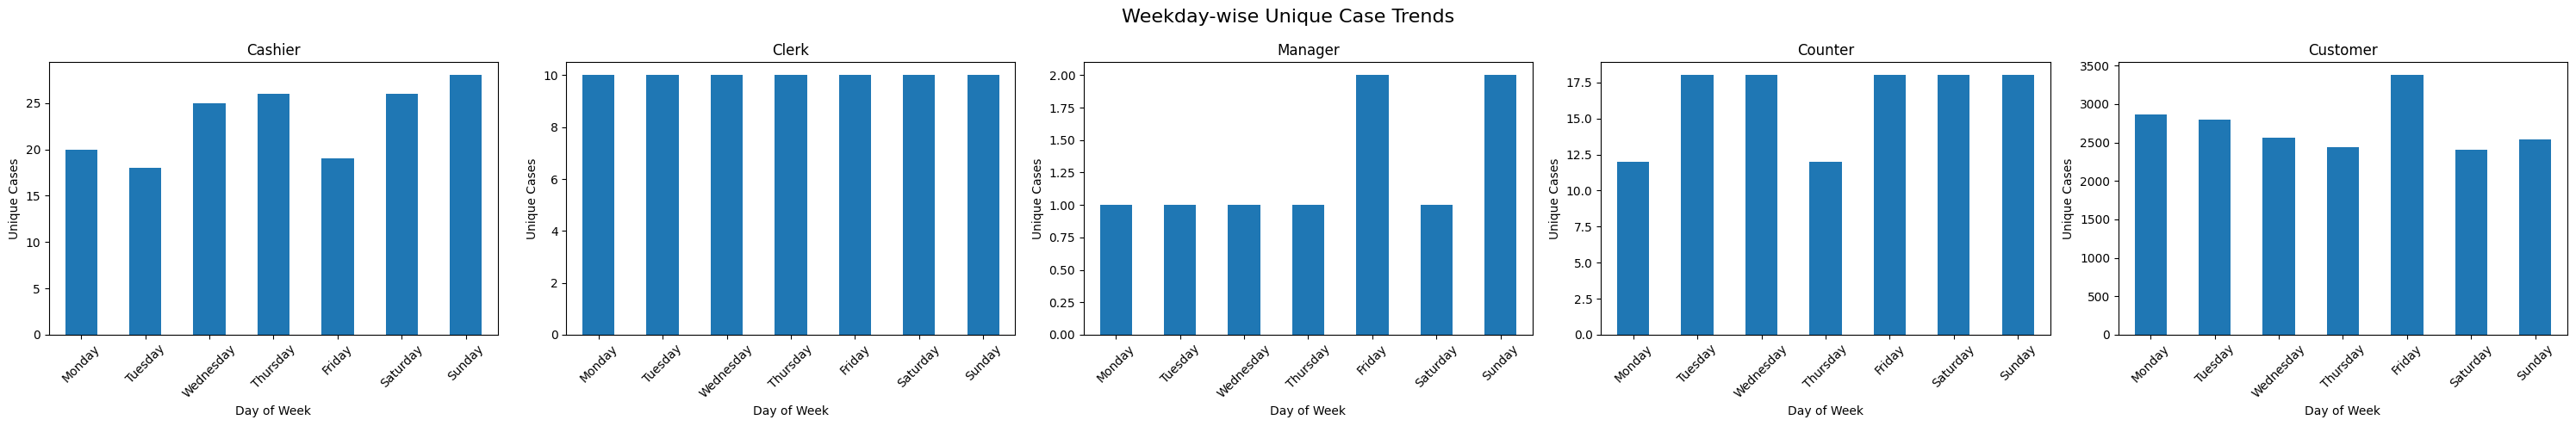

In [23]:
#cross checing with cse wie analysis as well
import matplotlib.pyplot as plt

# Add weekday column to each log
log_df_cashier['weekday'] = (
    log_df_cashier['time:timestamp']
    .dt.day_name()
)

log_df_clerk['weekday'] = (
    log_df_clerk['time:timestamp']
    .dt.day_name()
)

log_df_manager['weekday'] = (
    log_df_manager['time:timestamp']
    .dt.day_name()
)

log_df_counter['weekday'] = (
    log_df_counter['time:timestamp']
    .dt.day_name()
)

log_df_customer['weekday'] = (
    log_df_customer['time:timestamp']
    .dt.day_name()
)

# ------------------------------------------------
# Correct weekday order
# ------------------------------------------------

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# ------------------------------------------------
# UNIQUE CASES BY WEEKDAY
# ------------------------------------------------

cashier_weekday = (
    log_df_cashier.groupby('weekday')
    ['case:concept:name']
    .nunique()
    .reindex(weekday_order)
)

clerk_weekday = (
    log_df_clerk.groupby('weekday')
    ['case:concept:name']
    .nunique()
    .reindex(weekday_order)
)

manager_weekday = (
    log_df_manager.groupby('weekday')
    ['case:concept:name']
    .nunique()
    .reindex(weekday_order)
)

counter_weekday = (
    log_df_counter.groupby('weekday')
    ['case:concept:name']
    .nunique()
    .reindex(weekday_order)
)

customer_weekday = (
    log_df_customer.groupby('weekday')
    ['case:concept:name']
    .nunique()
    .reindex(weekday_order)
)

# ------------------------------------------------
# CREATE SUBPLOTS
# ------------------------------------------------

fig, axes = plt.subplots(
    1, 5,
    figsize=(30,5)
)

# Cashier
cashier_weekday.plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title("Cashier")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Unique Cases")

axes[0].tick_params(
    axis='x',
    rotation=45
)

# Clerk
clerk_weekday.plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Clerk")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Unique Cases")

axes[1].tick_params(
    axis='x',
    rotation=45
)

# Manager
manager_weekday.plot(
    kind='bar',
    ax=axes[2]
)

axes[2].set_title("Manager")
axes[2].set_xlabel("Day of Week")
axes[2].set_ylabel("Unique Cases")

axes[2].tick_params(
    axis='x',
    rotation=45
)

# Counter
counter_weekday.plot(
    kind='bar',
    ax=axes[3]
)

axes[3].set_title("Counter")
axes[3].set_xlabel("Day of Week")
axes[3].set_ylabel("Unique Cases")

axes[3].tick_params(
    axis='x',
    rotation=45
)

# Customer
customer_weekday.plot(
    kind='bar',
    ax=axes[4]
)

axes[4].set_title("Customer")
axes[4].set_xlabel("Day of Week")
axes[4].set_ylabel("Unique Cases")

axes[4].tick_params(
    axis='x',
    rotation=45
)

# Main title
fig.suptitle(
    "Weekday-wise Unique Case Trends",
    fontsize=16
)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

In [24]:
import pandas as pd

# Ensure timestamp is datetime
log_df_cashier['time:timestamp'] = pd.to_datetime(
    log_df_cashier['time:timestamp']
)

# Extract date and weekday
log_df_cashier['date'] = log_df_cashier['time:timestamp'].dt.date
log_df_cashier['weekday'] = log_df_cashier['time:timestamp'].dt.day_name()

# Keep only weekends
weekend_df = log_df_cashier[
    log_df_cashier['weekday'].isin(['Saturday', 'Sunday'])
]

#Weekdays
weekday_df = log_df_cashier[
    log_df_cashier['weekday'].isin([
        'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'
    ])
]
# Find opening and closing times per day
weekend_hours = weekend_df.groupby('date')['time:timestamp'].agg(
    opening_time='min',
    closing_time='max'
)
#Find opening and closing times per day
weekday_hours = weekday_df.groupby('date')['time:timestamp'].agg(  
    opening_time='min',
    closing_time='max'
)

# Compute duration
weekend_hours['open_duration'] = (
    weekend_hours['closing_time']
    - weekend_hours['opening_time']
)

# Convert duration to hours
weekend_hours['open_duration_hours'] = (
    weekend_hours['open_duration'].dt.total_seconds() / 3600
)

#Compute duration
weekday_hours['open_duration'] = (
    weekday_hours['closing_time']
    - weekday_hours['opening_time']
)

# Convert duration to hours
weekday_hours['open_duration_hours'] = (
    weekday_hours['open_duration'].dt.total_seconds() / 3600
)



In [25]:
print(weekend_hours)

                        opening_time                     closing_time  \
date                                                                    
2026-01-31 2026-01-31 14:00:00+00:00 2026-01-31 22:04:07.956000+00:00   
2026-02-01 2026-02-01 14:00:00+00:00 2026-02-01 22:01:45.051000+00:00   
2026-02-07 2026-02-07 14:00:00+00:00        2026-02-07 22:00:00+00:00   
2026-02-08 2026-02-08 14:00:00+00:00 2026-02-08 22:05:50.433000+00:00   
2026-02-14 2026-02-14 14:00:00+00:00 2026-02-14 22:05:12.727000+00:00   
2026-02-15 2026-02-15 14:00:00+00:00 2026-02-15 22:07:29.910000+00:00   
2026-02-21 2026-02-21 14:00:00+00:00 2026-02-21 22:07:09.664000+00:00   
2026-02-22 2026-02-22 14:00:00+00:00 2026-02-22 22:09:03.237000+00:00   
2026-02-28 2026-02-28 14:00:00+00:00 2026-02-28 22:07:53.116000+00:00   
2026-03-01 2026-03-01 14:00:00+00:00 2026-03-01 22:02:51.305000+00:00   

                    open_duration  open_duration_hours  
date                                                    
2026-01-3

In [26]:
print(weekend_hours)

                        opening_time                     closing_time  \
date                                                                    
2026-01-31 2026-01-31 14:00:00+00:00 2026-01-31 22:04:07.956000+00:00   
2026-02-01 2026-02-01 14:00:00+00:00 2026-02-01 22:01:45.051000+00:00   
2026-02-07 2026-02-07 14:00:00+00:00        2026-02-07 22:00:00+00:00   
2026-02-08 2026-02-08 14:00:00+00:00 2026-02-08 22:05:50.433000+00:00   
2026-02-14 2026-02-14 14:00:00+00:00 2026-02-14 22:05:12.727000+00:00   
2026-02-15 2026-02-15 14:00:00+00:00 2026-02-15 22:07:29.910000+00:00   
2026-02-21 2026-02-21 14:00:00+00:00 2026-02-21 22:07:09.664000+00:00   
2026-02-22 2026-02-22 14:00:00+00:00 2026-02-22 22:09:03.237000+00:00   
2026-02-28 2026-02-28 14:00:00+00:00 2026-02-28 22:07:53.116000+00:00   
2026-03-01 2026-03-01 14:00:00+00:00 2026-03-01 22:02:51.305000+00:00   

                    open_duration  open_duration_hours  
date                                                    
2026-01-3

In [27]:
avg_duration = weekend_hours['open_duration_hours'].mean()

print("Average weekend opening duration:",
      round(avg_duration, 2), "hours")

Average weekend opening duration: 8.09 hours


In [30]:
avg_duration = weekday_hours['open_duration_hours'].mean()


print("Average weekday opening duration:",
      round(avg_duration, 2), "hours")

Average weekday opening duration: 8.1 hours


In [31]:
log_df_counter['case:concept:name'].unique()

array(['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '2', '3',
       '4', '5', '6', '7', '8', '9'], dtype=object)

In [32]:
log_df_customer['cid'].unique()

array([nan,  0.,  7.,  3.,  1.,  6.,  8.,  2.,  5.,  4., 12., 11.,  9.,
       10., 13., 14., 17., 15., 16.])

In [33]:
import ast
import pandas as pd

# Function to compute queue length
def queue_length(q):
    
    # Skip NaN
    if pd.isna(q):
        return None
    
    # Convert string to list if needed
    if isinstance(q, str):
        q = ast.literal_eval(q)
    
    # Skip empty queues
    if len(q) == 0:
        return None
    
    # Return queue length
    return len(q)

# Create queue length column
log_df_counter['queue_length'] = (
    log_df_counter['q'].apply(queue_length)
)

# Remove empty queues
filtered_df = log_df_counter.dropna(
    subset=['queue_length']
)

# Keep only counter ID and queue length
result = filtered_df[
    ['case:concept:name', 'queue_length']
]

print(result.head(170000))

       case:concept:name  queue_length
0                      0          17.0
54                     0           1.0
55                     0           1.0
56                     0           1.0
57                     0           1.0
...                  ...           ...
581914                 2           1.0
581915                 2           1.0
581916                 2           1.0
581917                 2           1.0
581918                 2           1.0

[170000 rows x 2 columns]


In [66]:
log_df_customer_sorted.iloc[2000:2100]

,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp,p,col,...,i,q,pc,mC,mI,iMC,cid,b,clid,case:concept:name
2000,lRandom,Scan Item,NaN,NaN,NaN,complete,76.0,2026-02-10 18:22:40.107000+00:00,Pin,"[(0,0,0,false),(1,0,0,true),(2,0,0,true),(3,1,...",...,76.0,[],0.0,0.0,0.0,1.0,8.0,False,NaN,1002
2001,lRandom,Scan Item,NaN,NaN,NaN,complete,75.0,2026-02-10 18:22:43.375000+00:00,Pin,"[(0,0,0,false),(1,0,0,true),(2,0,0,true),(3,1,...",...,75.0,[],0.0,0.0,0.0,1.0,8.0,False,NaN,1002
2002,lRandom,Scan Item,NaN,NaN,NaN,complete,74.0,2026-02-10 18:22:45.862000+00:00,Pin,"[(0,0,0,false),(1,0,0,true),(2,0,0,true),(3,1,...",...,74.0,[],0.0,0.0,0.0,1.0,8.0,False,NaN,1002
2003,lRandom,Scan Item,NaN,NaN,NaN,complete,73.0,2026-02-10 18:22:48.625000+00:00,Pin,"[(0,0,0,false),(1,0,0,true),(2,0,0,true),(3,1,...",...,73.0,[],0.0,0.0,0.0,1.0,8.0,False,NaN,1002
2004,lRandom,Scan Item,NaN,NaN,NaN,complete,72.0,2026-02-10 18:22:51.924000+00:00,Pin,"[(0,0,0,false),(1,0,0,true),(2,0,0,true),(3,1,...",...,72.0,[],0.0,0.0,0.0,1.0,8.0,False,NaN,1002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095,lCust,Pickup Item,NaN,12.0,NaN,complete,60.0,2026-02-21 18:44:13.503000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1002
2096,lCust,Pickup Item,NaN,13.0,NaN,complete,60.0,2026-02-21 18:44:17.233000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1002
2097,lCust,Pickup Item,NaN,14.0,NaN,complete,60.0,2026-02-21 18:44:19.665000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1002
2098,lCust,Pickup Item,NaN,15.0,NaN,complete,60.0,2026-02-21 18:44:22.126000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1002


In [77]:
log_df_counter_sorted.head(60)

,col,q,concept:name,iMI,d,mC,caid,lifecycle:transition,mI,time:timestamp,...,p,s,pc,id,items,b,clid,cnt,x,case:concept:name
0,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,-1.0,4.0,0.0,2.0,complete,0.0,2026-01-26 14:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,"[(0,0,0,true),(1,0,0,false),(2,0,0,false),(3,0...",[],Enter Queue,0.0,NaN,0.0,NaN,complete,0.0,2026-01-26 14:03:27.627000+00:00,...,Pin,lItem,0.0,0.0,58.0,NaN,NaN,NaN,NaN,0
2,"[(0,1,58,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,58.0,2026-01-26 14:03:30.466000+00:00,...,Pin,lItem,0.0,0.0,58.0,False,NaN,NaN,NaN,0
3,"[(0,1,57,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,57.0,2026-01-26 14:03:34.164000+00:00,...,Pin,lItem,0.0,0.0,57.0,True,NaN,NaN,NaN,0
4,"[(0,1,56,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,56.0,2026-01-26 14:03:37.690000+00:00,...,Pin,lItem,1.0,0.0,56.0,False,NaN,NaN,NaN,0
5,NaN,NaN,Start Price Check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:37.690000+00:00,...,NaN,NaN,NaN,0.0,NaN,NaN,105.0,NaN,NaN,0
6,"[(0,1,55,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,55.0,2026-01-26 14:03:40.586000+00:00,...,Pin,lItem,1.0,0.0,55.0,False,NaN,NaN,NaN,0
7,"[(0,1,54,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,54.0,2026-01-26 14:03:42.967000+00:00,...,Pin,lItem,1.0,0.0,54.0,False,NaN,NaN,NaN,0
8,NaN,[],End price check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:44.083000+00:00,...,NaN,NaN,1.0,0.0,NaN,NaN,105.0,NaN,NaN,0
9,"[(0,1,53,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,53.0,2026-01-26 14:03:45.388000+00:00,...,Pin,lItem,0.0,0.0,53.0,False,NaN,NaN,NaN,0


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep only "Enter Queue" events
enter_queue_df = log_df_counter[
    log_df_counter['concept:name'] == 'Enter Queue'
]

# Count unique customers per counter
customers_per_counter = (
    enter_queue_df.groupby('case:concept:name')['id']
    .nunique()
)

print(customers_per_counter)

case:concept:name
0     2726
1     1519
10    1276
11    1428
12     884
13     816
14     521
15     462
16     341
17     317
2     1672
3     1504
4     1502
5     1595
6     1778
7     1754
8     1606
9     1316
Name: id, dtype: int64


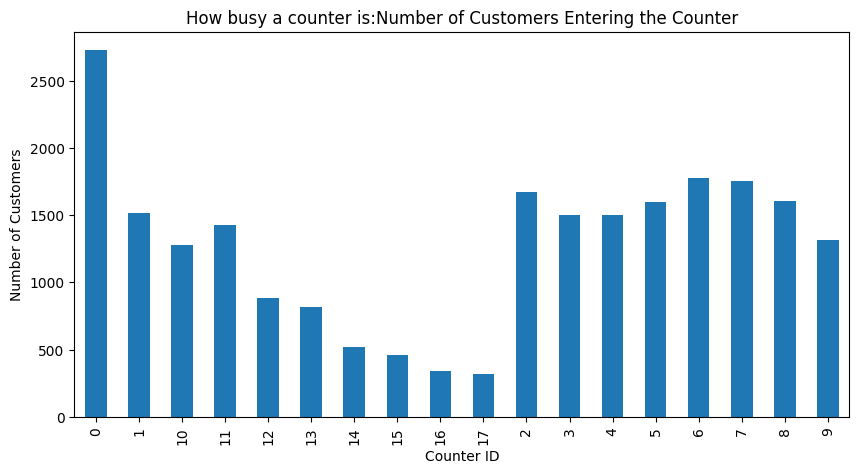

In [37]:
customers_per_counter.plot(
    kind='bar',
    figsize=(10,5)
)

plt.xlabel("Counter ID")
plt.ylabel("Number of Customers")
plt.title("How busy a counter is:Number of Customers Entering the Counter")

plt.show()

(The timings and peak were extracted from Line Chart below)
1) Counter 0 opens at 14:00 (all day) peak observed at 14:00 (greatest) then at 20:00 in this counter
2) Counter 1-5 open at 15:00
3) Counter 6,7,8 open at 16:00   peak observed at 19:00 in this counter; follow same pattern
4) Counter 10,9 open at 17:00 but twice as many customers at counter 9 as opposed to counter 10 at 17:00 peak at 19:00
4) Counter 11,12, 13 opens at 18:00 peak at 19:00 customers at 500,350,300 at peak
6) Counter 14 opens at 19:00 peaks at 20:00
7) Counter 15,16,17 opens at 20:00 but more customers flock to 15 (300) as compared to 16(200).
-----------------------------------------------------------------------------------------------
2) Counters 12-17 are not fully utilised because the averages remain stable while customers drop showcasing wasted resources
3) Counters 14–16 serve comparatively fewer customers because they are activated only during late peak-demand intervals. However, their average queue lengths remain relatively high because their operational periods coincide almost exclusively with the supermarket’s highest congestion window between 19:00 and 20:00.



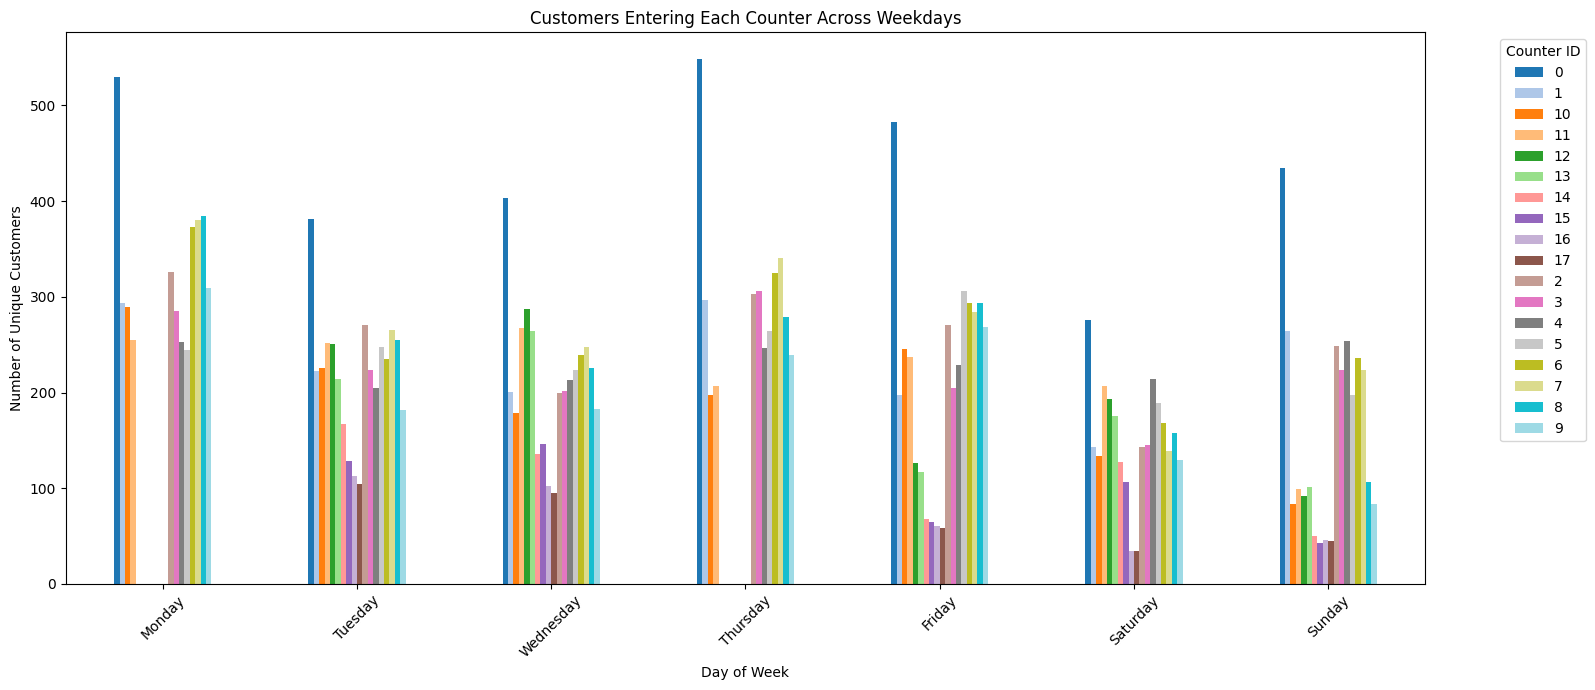

In [43]:
#Doing a weekday-wise analysis of the customers entering each counter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Keep only Enter Queue events
enter_queue_df_weekday = log_df_counter[
    log_df_counter['concept:name'] == 'Enter Queue'
].copy()

# Correct weekday ordering
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Count unique customers per weekday per counter
customers_per_counter_weekday = (
    enter_queue_df_weekday.groupby(
        ['weekday', 'case:concept:name']
    )['id']
    .nunique()
    .unstack(fill_value=0)
    .reindex(weekday_order)
)
# Number of counters
num_counters = len(
    customers_per_counter_weekday.columns
)
# Generate distinct colors
colors = plt.cm.tab20(
    np.linspace(0, 1, num_counters)
)
# Visualize
customers_per_counter_weekday.plot(
    kind='bar',
    figsize=(16,7), color=colors
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Unique Customers")

plt.title(
    "Customers Entering Each Counter Across Weekdays"
)

plt.legend(
    title="Counter ID",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure timestamp is datetime
log_df_counter['time:timestamp'] = pd.to_datetime(
    log_df_counter['time:timestamp']
)

# Keep only "Enter Queue" events
enter_queue_df = log_df_counter[
    log_df_counter['concept:name'] == 'Enter Queue'
].copy()

# Extract hour
enter_queue_df['hour'] = (
    enter_queue_df['time:timestamp'].dt.hour
)

# Count unique customers per hour per counter
hourly_customers = (
    enter_queue_df.groupby(
        ['hour', 'case:concept:name']
    )['id']
    .nunique()
    .unstack(fill_value=0)
)

print(hourly_customers)

case:concept:name    0    1   10   11   12   13   14   15   16   17    2    3  \
hour                                                                            
14                 734    0    0    0    0    0    0    0    0    0    0    0   
15                 349  370    0    0    0    0    0    0    0    0  358  393   
16                 417  423    0    0    0    0    0    0    0    0  423  446   
17                 352  324  189    0    0    0    0    0    0    0  281  302   
18                 143  270  255  270  154  120    0    0    0    0  300  252   
19                 265   62  516  524  343  306   83    0    0    0  117   71   
20                 461  104  226  426  277  265  295  304  219  210  173   72   
21                 254   46  129  249  144  142  148  167  120  109   77   30   
22                  16    2    3    8    3    5    6    4    7    3    2    0   

case:concept:name    4    5    6    7    8    9  
hour                                             
14      

In [45]:
import pandas as pd
import plotly.express as px

# Ensure timestamp is datetime
log_df_counter['time:timestamp'] = pd.to_datetime(
    log_df_counter['time:timestamp']
)

# Keep only "Enter Queue" events
enter_queue_df = log_df_counter[
    log_df_counter['concept:name'] == 'Enter Queue'
].copy()

# Extract hour
enter_queue_df['hour'] = (
    enter_queue_df['time:timestamp'].dt.hour
)

# Count unique customers per hour per counter
hourly_customers = (
    enter_queue_df.groupby(
        ['hour', 'case:concept:name']
    )['id']
    .nunique()
    .reset_index(name='customer_count')
)

# Convert counter IDs to string for cleaner legend
hourly_customers['case:concept:name'] = (
    hourly_customers['case:concept:name'].astype(str)
)

# Interactive plot
fig = px.line(
    hourly_customers,
    x='hour',
    y='customer_count',
    color='case:concept:name',
    markers=True,
    title='Hourly Customer Arrivals per Counter',
    labels={
        'hour': 'Hour of Day',
        'customer_count': 'Number of Unique Customers',
        'case:concept:name': 'Counter ID'
    }
)

# Improve layout
fig.update_layout(
    hovermode='x unified',
    legend_title='Counter ID'
)

# Show interactive graph
fig.show()

1) Counter 0 opens at 14:00 (all day) peak observed at 14:00 (greatest) then at 20:00 in this counter however only counters 6,7,8 experience peak at 20:00 but only a decline observed  3,4,5
2) Counter 1-5 open at 15:00
3) Counter 6,7,8 open at 16:00   peak observed at 19:00 in this counter; follow same pattern
4) Counter 10,9 open at 17:00 but twice as many customers at counter 9 as opposed to counter 10 at 17:00 peak at 19:00; 
5) Counter 11,12, 13 opens at 18:00 peak at 19:00 customers at 500,350,300 at peak
6) Counter 14 opens at 19:00 peaks at 20:00
7) Counter 15,16,17 opens at 20:00 but more customers flock to 15 (300) as compared to 16(200).
8) Counters 20:00-22:00 not being fully utilised
----------------------------------------------------------------------------------------------------------------------

1) Counter 9,10:
spatial preference,
shorter walking distance,
cashier efficiency,
queue perception,
customer routing bias. 
This is valuable managerial insight because:
merely opening counters does not guarantee balanced utilization.

2) Counter 15 this may indicate:
customer preference,
physical positioning,
cashier speed reputation,



Key Insights You Can Report

You can formally state:

1) Counter 0 acts as the primary always-open counter and experiences the highest sustained congestion.
2) Counter activation follows a demand-driven temporal strategy, with additional counters progressively opening during later hours.
3) Peak supermarket activity occurs around 19:00–20:00.
4) Customer distribution across counters is uneven despite simultaneous availability of counters.
5) Some counters exhibit disproportionately high queue lengths relative to customer volume, suggesting efficiency differences.
6) Late-opened counters receive significantly lower traffic, indicating possible overprovisioning during late evening periods.

**Temporal Anlaysis-Visualising Cart Abandonments**


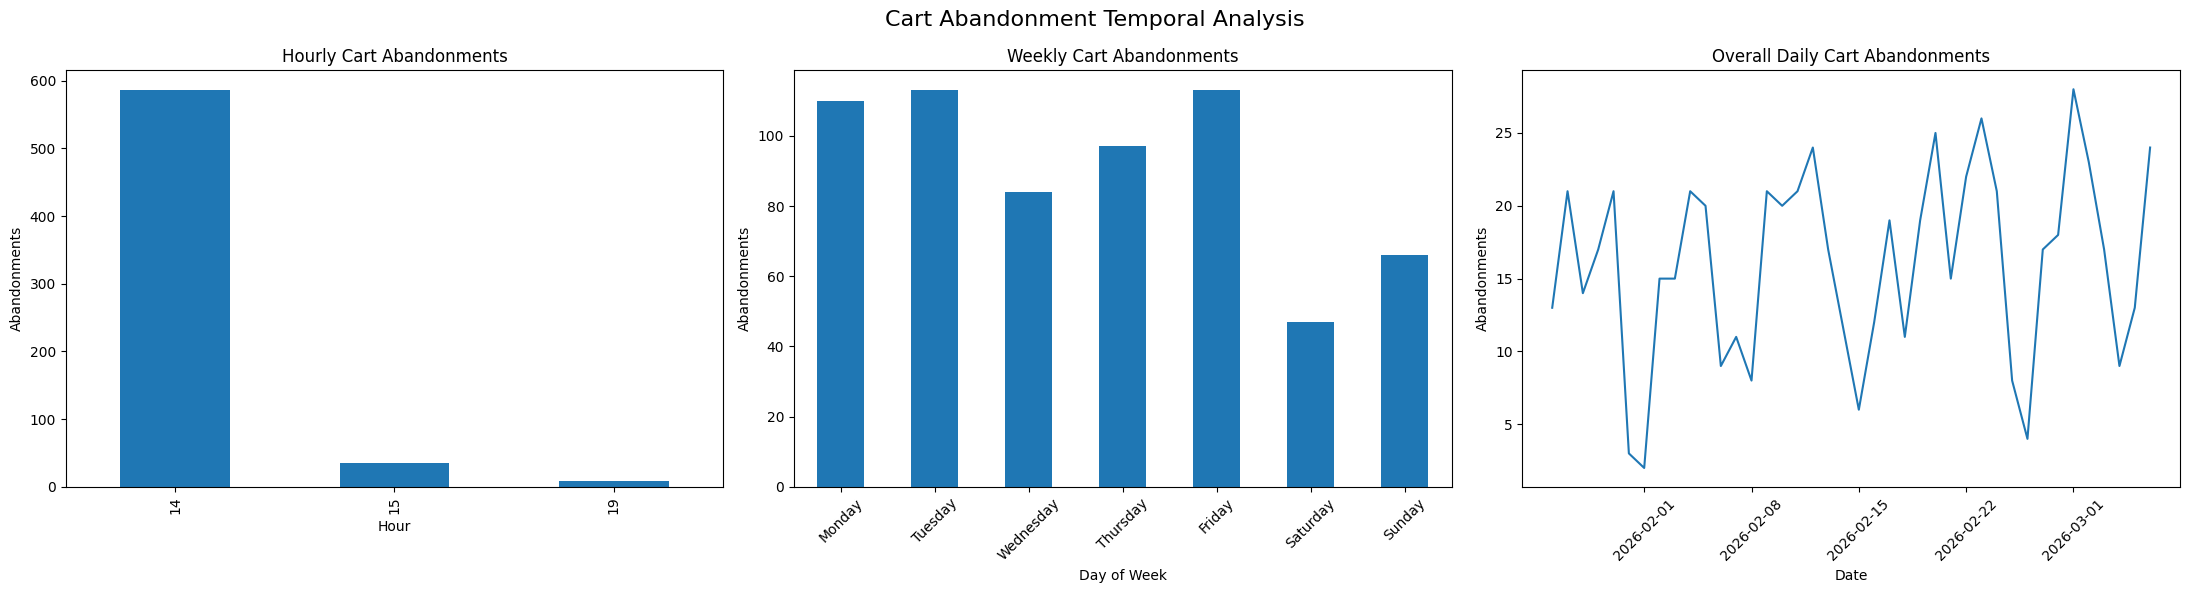

In [46]:


# Ensure timestamp is datetime
log_df_customer['time:timestamp'] = pd.to_datetime(
    log_df_customer['time:timestamp']
)

# Filter abandonment events
abandonments = log_df_customer[
    log_df_customer['concept:name'] == 'Abandon cart and leave'
].copy()

# -----------------------------
# HOURLY ANALYSIS
# -----------------------------
abandonments['hour'] = (
    abandonments['time:timestamp'].dt.hour
)

hourly_abandonments = (
    abandonments.groupby('hour')
    .size()
)

# -----------------------------
# WEEKDAY ANALYSIS
# -----------------------------
abandonments['weekday'] = (
    abandonments['time:timestamp'].dt.day_name()
)

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

weekly_abandonments = (
    abandonments.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

# -----------------------------
# DAILY / OVERALL TREND
# -----------------------------
abandonments['date'] = (
    abandonments['time:timestamp'].dt.date
)

daily_abandonments = (
    abandonments.groupby('date')
    .size()
)

# -----------------------------
# VISUALIZATION
# Each plot has independent scale
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(22,6))

# Hourly
hourly_abandonments.plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title("Hourly Cart Abandonments")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Abandonments")

# Weekly
weekly_abandonments.plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Weekly Cart Abandonments")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Abandonments")

axes[1].tick_params(axis='x', rotation=45)

# Daily / Overall
daily_abandonments.plot(
    ax=axes[2]
)

axes[2].set_title("Overall Daily Cart Abandonments")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Abandonments")

axes[2].tick_params(axis='x', rotation=45)

# Main title
fig.suptitle(
    "Cart Abandonment Temporal Analysis",
    fontsize=16
)

# Separate scales automatically maintained
plt.tight_layout()

plt.show()

1) Wednesday (essential buying, task oriented, maybe promotions as well) and Saturday (because more time) Lowest Abandonments
2) Carnival, Holiday Season a lot of cart Abandonments even on Sunday which is otherwise the lowest
3) Tuesday and Friday very high abandonments
4) Limited Counter at 14:00 can be reason why abandonement is so high here 
5) Counters open at 15:00, 19:00 so that long queues cannot be the sole reason of cart abandonment there
6) Similar customers on Sunday and Saturday but Sunday has more abandonments esp 22/02/2026 and 01/03/2026
7) By Sunday, popular items may be out of stock, causing shoppers to abandon their entire cart, particularly for "meal-for-tonight" or "special-occasion" missions.


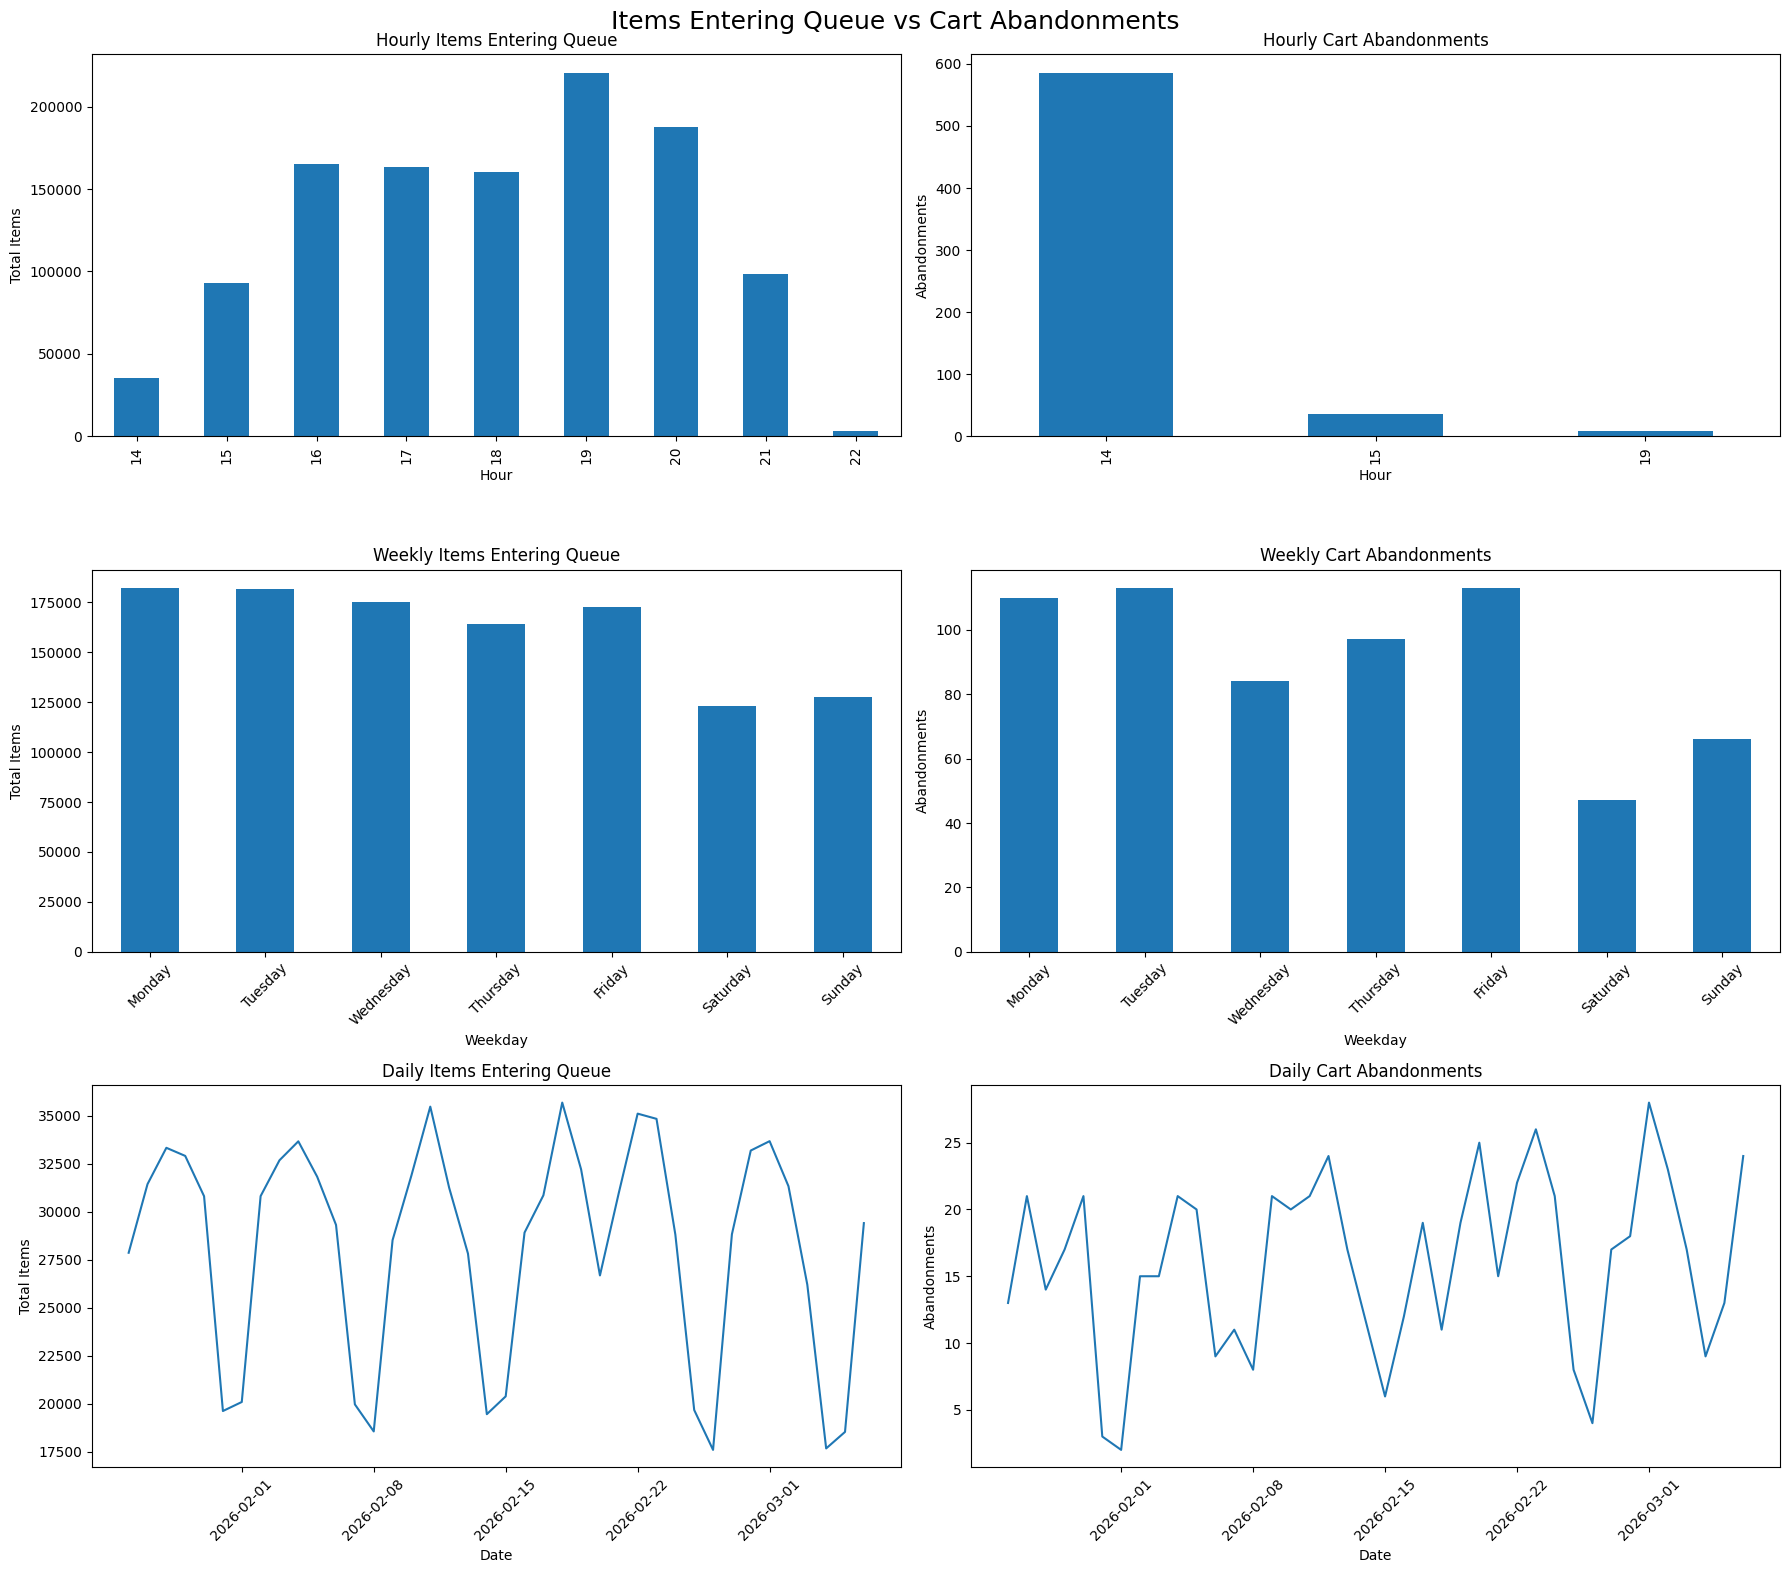

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure timestamp is datetime
log_df_customer['time:timestamp'] = pd.to_datetime(
    log_df_customer['time:timestamp']
)

log_df_customer_sorted['time:timestamp'] = pd.to_datetime(
    log_df_customer_sorted['time:timestamp']
)

# ---------------------------------------------------
# ENTER QUEUE EVENTS
# ---------------------------------------------------
enter_queue = log_df_customer[
    log_df_customer['concept:name'] == 'Enter Queue'
].copy()

# ---------------------------------------------------
# ABANDONMENT EVENTS
# ---------------------------------------------------
abandonments = log_df_customer_sorted[
    log_df_customer_sorted['concept:name'] == 'Abandon cart and leave'
].copy()

# ===================================================
# HOURLY ANALYSIS
# ===================================================

# Hour extraction
enter_queue['hour'] = (
    enter_queue['time:timestamp'].dt.hour
)

abandonments['hour'] = (
    abandonments['time:timestamp'].dt.hour
)

# Total items entering queue hourly
hourly_items = (
    enter_queue.groupby('hour')['items']
    .sum()
)

# Hourly abandonments
hourly_abandonments = (
    abandonments.groupby('hour')
    .size()
)

# ===================================================
# WEEKDAY ANALYSIS
# ===================================================

# Weekday extraction
enter_queue['weekday'] = (
    enter_queue['time:timestamp'].dt.day_name()
)

abandonments['weekday'] = (
    abandonments['time:timestamp'].dt.day_name()
)

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Weekly items
weekly_items = (
    enter_queue.groupby('weekday')['items']
    .sum()
    .reindex(weekday_order)
)

# Weekly abandonments
weekly_abandonments = (
    abandonments.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

# ===================================================
# DAILY ANALYSIS
# ===================================================

# Date extraction
enter_queue['date'] = (
    enter_queue['time:timestamp'].dt.date
)

abandonments['date'] = (
    abandonments['time:timestamp'].dt.date
)

# Daily items
daily_items = (
    enter_queue.groupby('date')['items']
    .sum()
)

# Daily abandonments
daily_abandonments = (
    abandonments.groupby('date')
    .size()
)

# ===================================================
# VISUALIZATION
# Separate scales for each graph
# ===================================================

fig, axes = plt.subplots(3, 2, figsize=(18, 16))

# ---------------- HOURLY ----------------

hourly_items.plot(
    kind='bar',
    ax=axes[0,0]
)

axes[0,0].set_title("Hourly Items Entering Queue")
axes[0,0].set_xlabel("Hour")
axes[0,0].set_ylabel("Total Items")

hourly_abandonments.plot(
    kind='bar',
    ax=axes[0,1]
)

axes[0,1].set_title("Hourly Cart Abandonments")
axes[0,1].set_xlabel("Hour")
axes[0,1].set_ylabel("Abandonments")

# ---------------- WEEKLY ----------------

weekly_items.plot(
    kind='bar',
    ax=axes[1,0]
)

axes[1,0].set_title("Weekly Items Entering Queue")
axes[1,0].set_xlabel("Weekday")
axes[1,0].set_ylabel("Total Items")

axes[1,0].tick_params(axis='x', rotation=45)

weekly_abandonments.plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Weekly Cart Abandonments")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel("Abandonments")

axes[1].tick_params(axis='x', rotation=45)

# ---------------- DAILY ----------------

daily_items.plot(
    ax=axes[2,0]
)

axes[2,0].set_title("Daily Items Entering Queue")
axes[2,0].set_xlabel("Date")
axes[2,0].set_ylabel("Total Items")

axes[2,0].tick_params(axis='x', rotation=45)

daily_abandonments.plot(
    ax=axes[2,1]
)

axes[2,1].set_title("Daily Cart Abandonments")
axes[2,1].set_xlabel("Date")
axes[2,1].set_ylabel("Abandonments")

axes[2,1].tick_params(axis='x', rotation=45)

# ---------------------------------------------------
# Main title
# ---------------------------------------------------
fig.suptitle(
    "Items Entering Queue vs Cart Abandonments",
    fontsize=18
)

plt.tight_layout()

plt.show()

## Hourly counter efficiency analysis

This cell computes, for each hour of day, the average number of unique customers, the average number of open counters, the average customers per open counter, and recommends the number of counters to open based on a target customers-per-counter threshold. It also plots the results and saves a CSV in `outputs/`.



COUNTER PERFORMANCE SUMMARY

            peak_customers  variability  active_hours  \
counter_id                                              
0                      734       203.81             9   
1                      423       167.96             8   
2                      423       155.19             8   
3                      446       175.61             7   
4                      430       159.13             7   
5                      379       154.88             7   
6                      533       190.05             6   
7                      548       188.11             7   
8                      509       180.33             7   
9                      481       178.26             6   
10                     516       173.82             6   
11                     524       208.75             5   
12                     343       134.44             5   
13                     306       122.69             5   
14                     295       102.72             4   
1

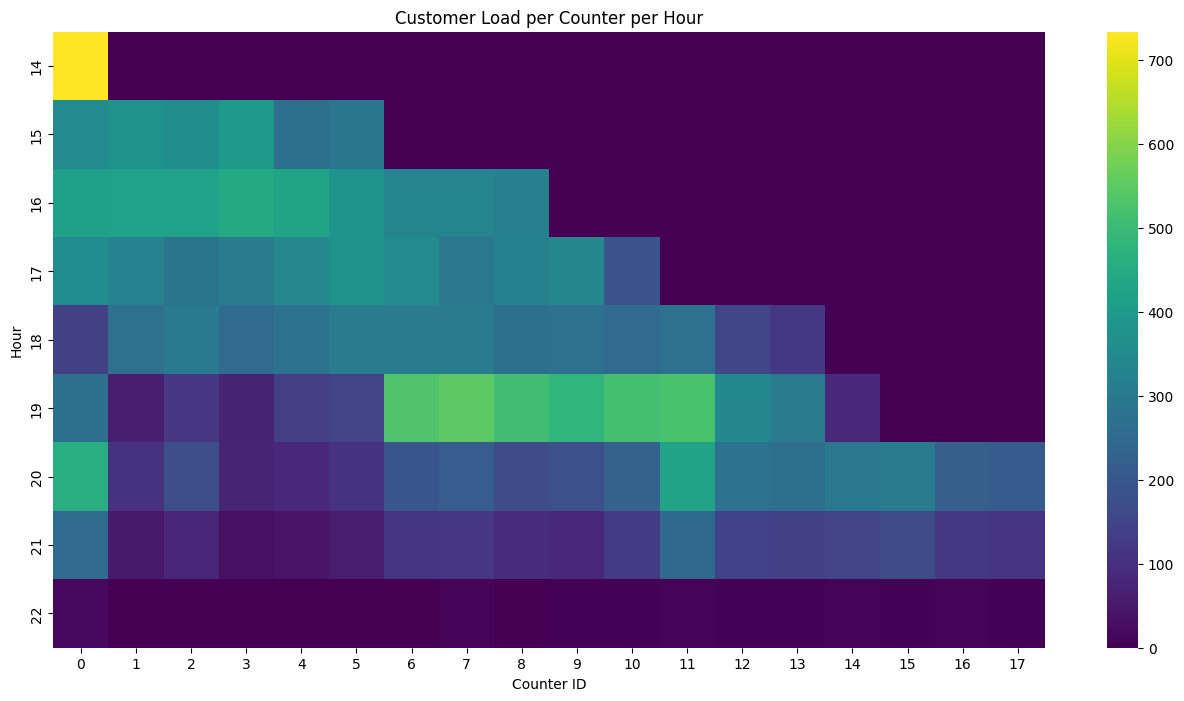

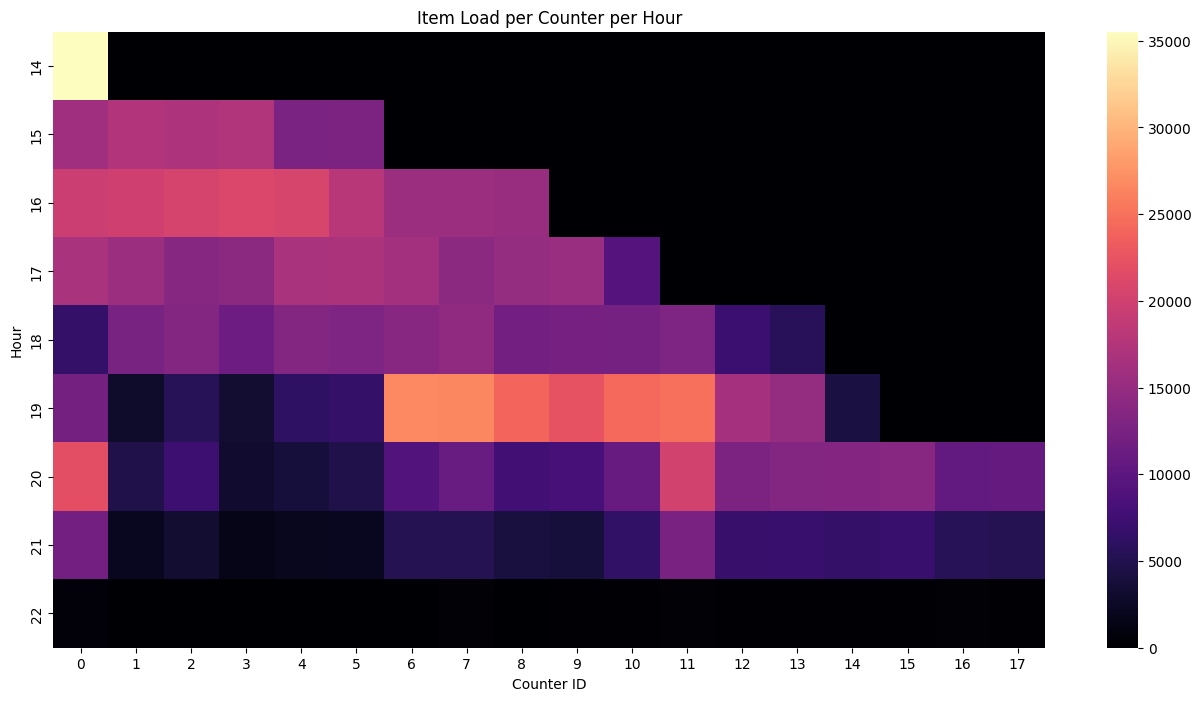

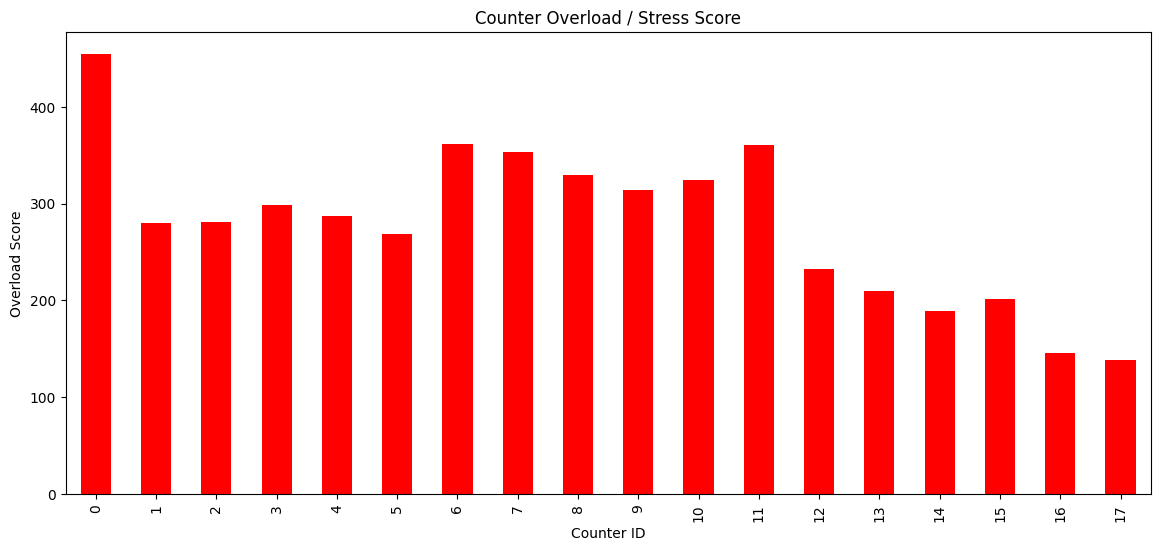

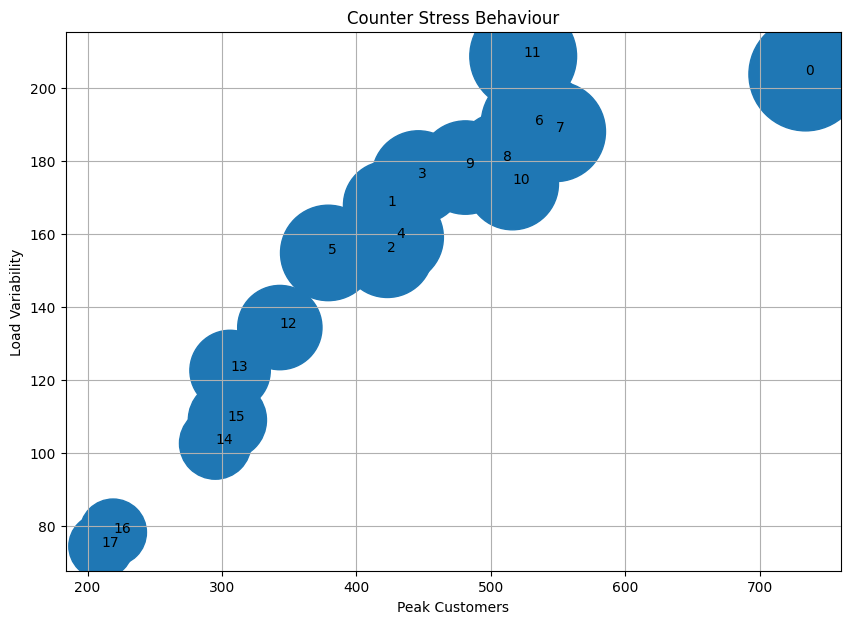

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. PREPARE DATA
# =========================================================

log_df_counter['time:timestamp'] = pd.to_datetime(
    log_df_counter['time:timestamp']
)

log_df_customer['time:timestamp'] = pd.to_datetime(
    log_df_customer['time:timestamp']
)

# =========================================================
# 2. ENTER QUEUE EVENTS
# =========================================================

enter_queue = log_df_counter[
    log_df_counter['concept:name']
    == 'Enter Queue'
].copy()

# =========================================================
# 3. NORMALIZE IDS
# =========================================================

enter_queue['id'] = (
    enter_queue['id']
    .astype(float)
    .astype(int)
)

enter_queue['counter_id'] = (
    enter_queue['case:concept:name']
    .astype(int)
)

# =========================================================
# 4. TEMPORAL FEATURES
# =========================================================

enter_queue['hour'] = (
    enter_queue['time:timestamp']
    .dt.hour
)

# =========================================================
# 5. CUSTOMER LOAD PER COUNTER PER HOUR
# =========================================================

customer_load = (
    enter_queue.groupby(
        ['hour', 'counter_id']
    )['id']
    .nunique()
    .unstack(fill_value=0)
)

# =========================================================
# 6. ITEM LOAD PER COUNTER PER HOUR
# =========================================================

item_load = (
    enter_queue.groupby(
        ['hour', 'counter_id']
    )['items']
    .sum()
    .unstack(fill_value=0)
)

# =========================================================
# 7. VARIABILITY (VERY IMPORTANT)
# =========================================================

counter_variability = (
    customer_load.std()
)

# =========================================================
# 8. PEAK LOAD
# =========================================================

peak_load = (
    customer_load.max()
)

# =========================================================
# 9. ACTIVE HOURS here also includes start and end hours 
# =========================================================

active_hours = (
    customer_load.gt(0)
    .sum()
)

# =========================================================
# 10. CUSTOMERS PER ACTIVE HOUR
# =========================================================

customers_per_active_hour = (
    customer_load.sum()
    /
    active_hours
)

# =========================================================
# 11. ITEMS PER ACTIVE HOUR
# =========================================================

items_per_active_hour = (
    item_load.sum()
    /
    active_hours
)

# =========================================================
# 12. OVERLOAD SCORE
# =========================================================
#
# Stronger than simple averages
#
# Higher score means:
# - high peaks
# - high variability
# - high sustained load
#
# =========================================================
#when max cutomers (as that would influence waiting +counters with spikes+customer per hour
#is on scale of customer
overload_score = (
    (
        peak_load * 0.4
    )
    +
    (
        counter_variability * 0.3
    )
    +
    (
        customers_per_active_hour * 0.3
    )
)

# =========================================================
# 13. COMBINE EVERYTHING
# =========================================================

analysis_df = pd.DataFrame({

    'peak_customers':
        peak_load,

    'variability':
        counter_variability,

    'active_hours':
        active_hours,

    'customers_per_active_hour':
        customers_per_active_hour,

    'items_per_active_hour':
        items_per_active_hour,

    'overload_score':
        overload_score

})

analysis_df = (
    analysis_df
    .round(2)
)

analysis_df.index = (
    analysis_df.index.astype(int)
)

analysis_df = (
    analysis_df.sort_index()
)

# =========================================================
# 14. PRINT RESULTS
# =========================================================

print("\nCOUNTER PERFORMANCE SUMMARY\n")

print(analysis_df)

# =========================================================
# 15. HEATMAP — CUSTOMER LOAD
# =========================================================

plt.figure(figsize=(16,8))

sns.heatmap(
    customer_load,
    cmap='viridis',
    annot=False
)

plt.title(
    "Customer Load per Counter per Hour"
)

plt.xlabel("Counter ID")

plt.ylabel("Hour")

plt.show()

# =========================================================
# 16. HEATMAP — ITEM LOAD
# =========================================================

plt.figure(figsize=(16,8))

sns.heatmap(
    item_load,
    cmap='magma',
    annot=False
)

plt.title(
    "Item Load per Counter per Hour"
)

plt.xlabel("Counter ID")

plt.ylabel("Hour")

plt.show()

# =========================================================
# 17. OVERLOAD SCORE VISUALIZATION
# =========================================================

plt.figure(figsize=(14,6))

analysis_df[
    'overload_score'
].plot(
    kind='bar',
    color='red'
)

plt.title(
    "Counter Overload / Stress Score"
)

plt.xlabel("Counter ID")

plt.ylabel("Overload Score")

plt.show()

# =========================================================
# 18. PEAK VS VARIABILITY SCATTER
# =========================================================

plt.figure(figsize=(10,7))

plt.scatter(
    analysis_df['peak_customers'],
    analysis_df['variability'],
    s=analysis_df[
        'customers_per_active_hour'
    ] * 20
)

# Add counter labels
for counter_id, row in analysis_df.iterrows():

    plt.text(
        row['peak_customers'],
        row['variability'],
        str(counter_id)
    )

plt.xlabel("Peak Customers")

plt.ylabel("Load Variability")

plt.title(
    "Counter Stress Behaviour"
)

plt.grid(True)

plt.show()

CLERK HOURLY SUMMARY FOR KEY HOURS


,customers,price_checks,cleaning,price_checks_per_customer,cleaning_per_customer
hour,,,,,
14,1288,749,2816,0.582,2.186
15,1750,2388,166,1.365,0.095
16,2446,4324,0,1.768,0.000
17,2425,4445,0,1.833,0.000
18,2459,4050,0,1.647,0.000
19,3070,5487,50,1.787,0.016
20,2848,5398,0,1.895,0.000
21,1824,2779,0,1.524,0.000
22,156,164,0,1.051,0.000


FULL HOURLY CLERK ACTIVITY SUMMARY


,customers,price_checks,cleaning,price_checks_per_customer,cleaning_per_customer
hour,,,,,
14,1288,749,2816,0.582,2.186
15,1750,2388,166,1.365,0.095
16,2446,4324,0,1.768,0.000
17,2425,4445,0,1.833,0.000
18,2459,4050,0,1.647,0.000
19,3070,5487,50,1.787,0.016
20,2848,5398,0,1.895,0.000
21,1824,2779,0,1.524,0.000
22,156,164,0,1.051,0.000


ACTIVITY SHARE AT KEY HOURS


,Start Price Check,Cleanup abandoned item,other_clerk_activity
hour,,,
14,0.106,0.790,0.104
15,0.472,0.065,0.463
16,0.501,0.000,0.499
17,0.501,0.000,0.499
18,0.502,0.000,0.498
19,0.495,0.009,0.496
20,0.498,0.000,0.502
21,0.497,0.000,0.503
22,0.433,0.000,0.567


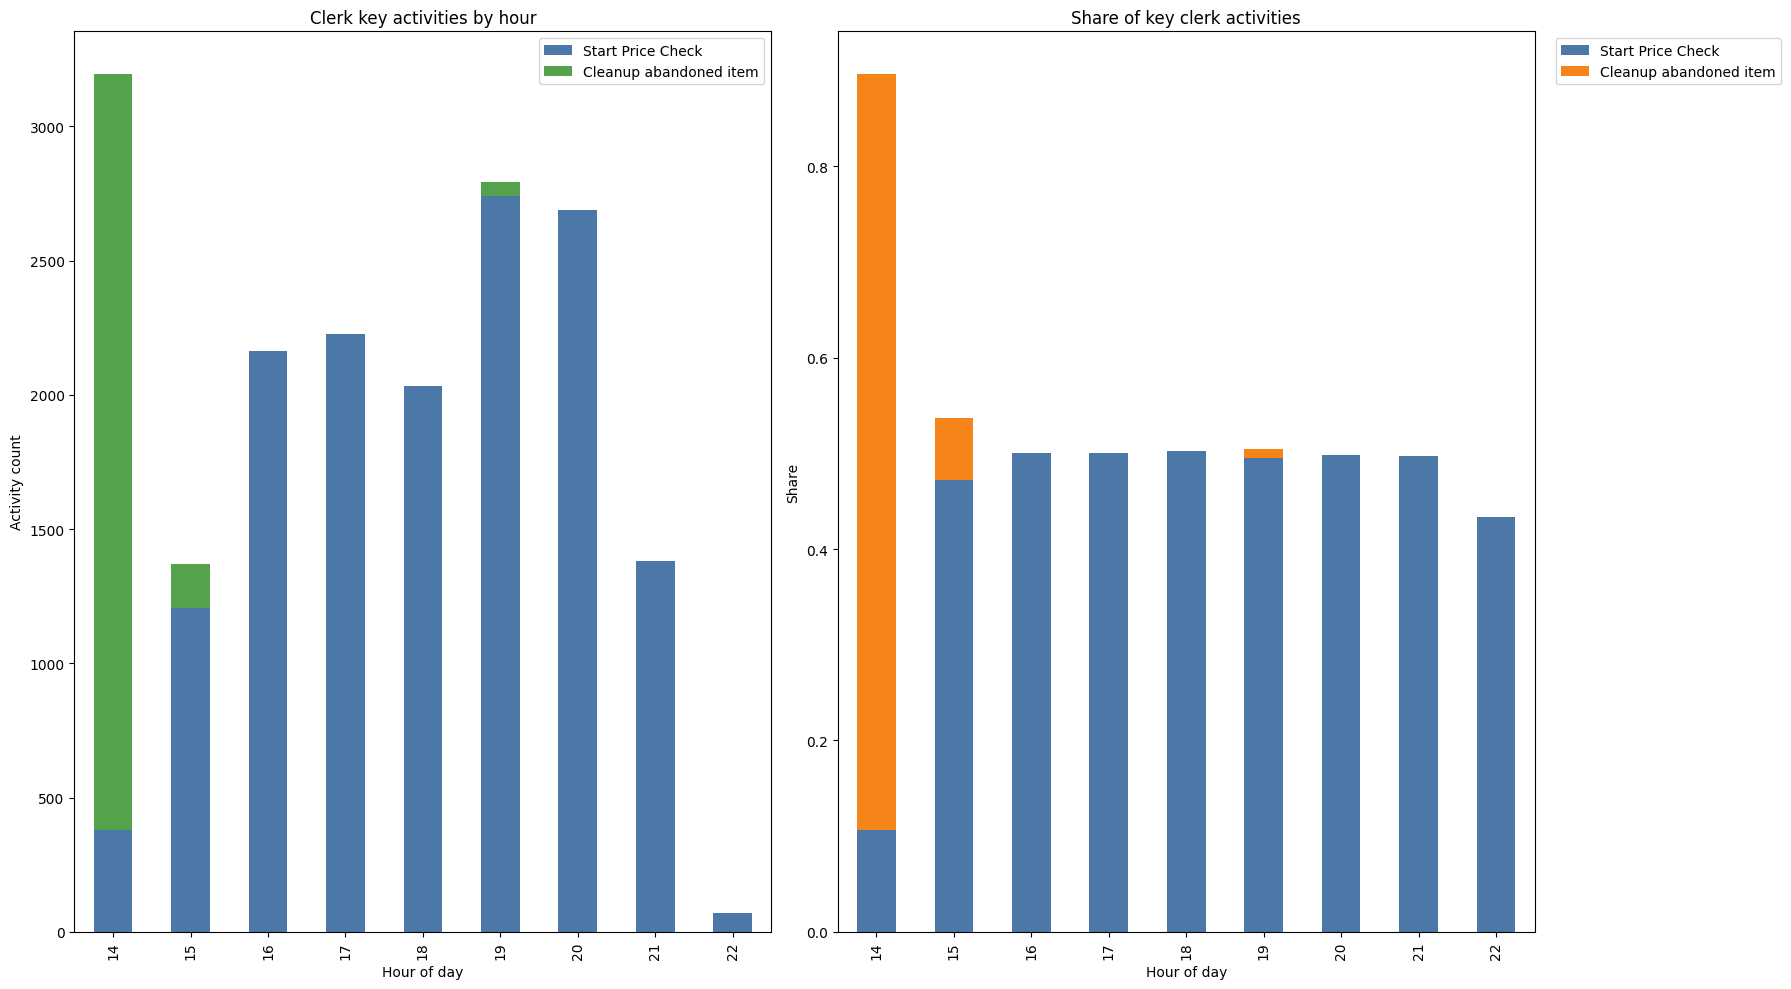

CRITICAL HOUR INTERPRETATION TABLE


,customers,price_checks,cleaning,price_checks_per_customer,cleaning_per_customer,price_checks_share,cleaning_share
hour,,,,,,,
14,1288,749,2816,0.582,2.186,0.210,0.790
15,1750,2388,166,1.365,0.095,0.935,0.065
16,2446,4324,0,1.768,0.000,1.000,0.000
17,2425,4445,0,1.833,0.000,1.000,0.000
18,2459,4050,0,1.647,0.000,1.000,0.000
19,3070,5487,50,1.787,0.016,0.991,0.009
20,2848,5398,0,1.895,0.000,1.000,0.000
21,1824,2779,0,1.524,0.000,1.000,0.000
22,156,164,0,1.051,0.000,1.000,0.000


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------
# Clerk hourly activity analysis focused on price checks and cleaning
# -------------------------------------------------------------------

# Make sure timestamps are parsed correctly
log_df_clerk['time:timestamp'] = pd.to_datetime(log_df_clerk['time:timestamp'], errors='coerce')
log_df_customer['time:timestamp'] = pd.to_datetime(log_df_customer['time:timestamp'], errors='coerce')

clerk_df = log_df_clerk.dropna(subset=['time:timestamp']).copy()
customer_df = log_df_customer.dropna(subset=['time:timestamp']).copy()

# Hour of day
clerk_df['hour'] = clerk_df['time:timestamp'].dt.hour
customer_df['hour'] = customer_df['time:timestamp'].dt.hour

# Keep only the activities that matter for this analysis
activity_col = 'concept:name'
key_activities = [
    'Start Price Check',
    'Cleanup abandoned item'
]

# All clerk activities by hour
clerk_hourly = (
    clerk_df.groupby(['hour', activity_col])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Ensure key activity columns exist even if absent in some data slices
for activity in key_activities:
    if activity not in clerk_hourly.columns:
        clerk_hourly[activity] = 0

clerk_hourly = clerk_hourly.sort_index(axis=1)

# Aggregate the main activity groups
clerk_hourly['price_checks'] = clerk_hourly[[c for c in clerk_hourly.columns if 'price check' in str(c).lower()]].sum(axis=1)
clerk_hourly['cleaning'] = clerk_hourly[[c for c in clerk_hourly.columns if 'clean' in str(c).lower()]].sum(axis=1)
clerk_hourly['total_clerk_events'] = clerk_hourly.drop(columns=['price_checks', 'cleaning']).sum(axis=1)

# Customer load per hour for influence comparison
customer_hourly = (
    customer_df.groupby('hour')['case:concept:name']
    .nunique()
    .rename('customers')
    .sort_index()
)

clerk_hourly = clerk_hourly.join(customer_hourly, how='outer').fillna(0)
clerk_hourly['customers'] = clerk_hourly['customers'].astype(int)

# Normalize price checks and cleaning relative to customer load
clerk_hourly['price_checks_per_customer'] = clerk_hourly['price_checks'] / clerk_hourly['customers'].replace(0, np.nan)
clerk_hourly['cleaning_per_customer'] = clerk_hourly['cleaning'] / clerk_hourly['customers'].replace(0, np.nan)

# Key hours of interest
key_hours = [14, 15,16,17,18,19,20,21,22]
key_hours_summary = clerk_hourly.loc[clerk_hourly.index.intersection(key_hours), [
    'customers', 'price_checks', 'cleaning', 'price_checks_per_customer', 'cleaning_per_customer'
]].copy()

print('CLERK HOURLY SUMMARY FOR KEY HOURS')
display(key_hours_summary.round(3))

print('FULL HOURLY CLERK ACTIVITY SUMMARY')
display(clerk_hourly[[
    'customers', 'price_checks', 'cleaning', 'price_checks_per_customer', 'cleaning_per_customer'
]].round(3))

# Share of activities by hour for the main operational actions
main_ops = clerk_hourly[['Start Price Check', 'Cleanup abandoned item']].copy()
main_ops['other_clerk_activity'] = clerk_hourly['total_clerk_events'] - main_ops.sum(axis=1)
main_ops = main_ops.clip(lower=0)

activity_share = main_ops.div(main_ops.sum(axis=1).replace(0, np.nan), axis=0)

print('ACTIVITY SHARE AT KEY HOURS')
display(activity_share.loc[activity_share.index.intersection(key_hours)].round(3))

# -------------------------------------------------------------------
# Visualizations
# -------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# 1) Stacked activity counts
clerk_hourly[['Start Price Check', 'Cleanup abandoned item']].plot(
    kind='bar', stacked=True, ax=axes[0], color=['#4C78A8', '#54A24B']
)
axes[0].set_title('Clerk key activities by hour')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Activity count')


# 4) Activity share at key hours
activity_share.loc[activity_share.index.intersection(key_hours), [
    'Start Price Check', 'Cleanup abandoned item'
]].plot(kind='bar', stacked=True, ax=axes[1], color=['#4C78A8', '#F58518', '#54A24B'])
axes[1].set_title('Share of key clerk activities')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Share')
axes[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Short critical interpretation table
# -------------------------------------------------------------------

critical_hours = clerk_hourly.loc[clerk_hourly.index.intersection(key_hours), [
    'customers', 'price_checks', 'cleaning', 'price_checks_per_customer', 'cleaning_per_customer'
]].copy()
critical_hours['price_checks_share'] = critical_hours['price_checks'] / critical_hours[['price_checks', 'cleaning']].sum(axis=1).replace(0, np.nan)
critical_hours['cleaning_share'] = critical_hours['cleaning'] / critical_hours[['price_checks', 'cleaning']].sum(axis=1).replace(0, np.nan)

print('CRITICAL HOUR INTERPRETATION TABLE')
display(critical_hours.round(3))



ABANDONMENT ANALYSIS


CUSTOMER TYPES DURING ABANDONMENT

s
lCust      220
lItem      214
lRandom    196
Name: count, dtype: int64
s     lCust  lItem  lRandom
hour                       
14      203    192      191
15       12     19        5
19        5      3        0


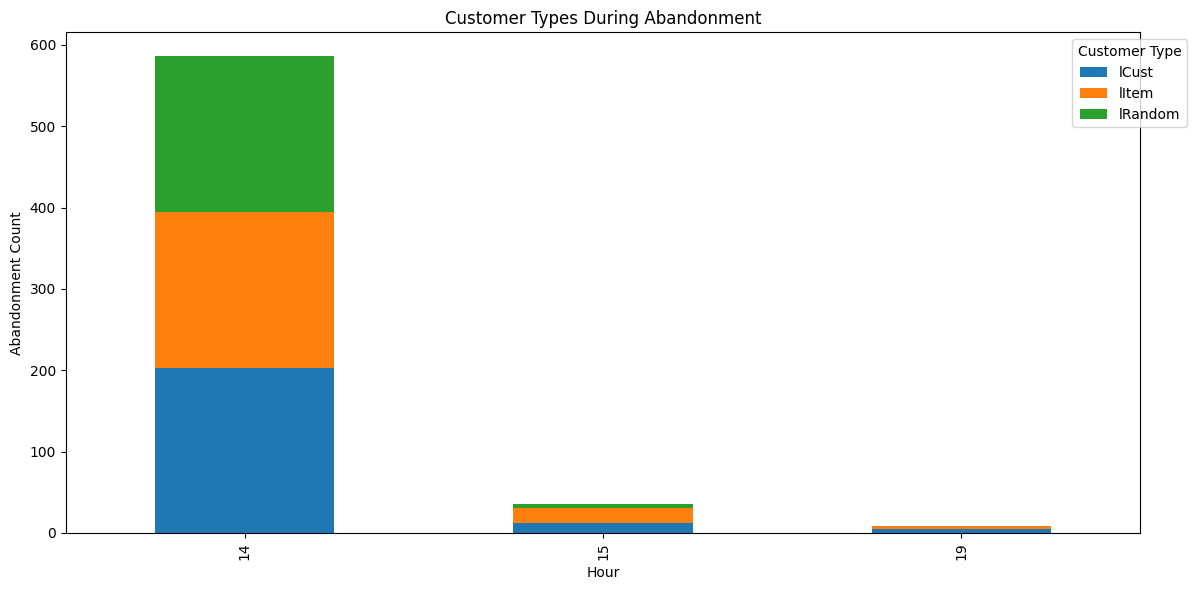


ABANDONMENT RATE (%)

s     lCust  lItem  lRandom
hour                       
14     0.58   0.55     0.59
15     0.02   0.03     0.01
19     0.00   0.00      NaN


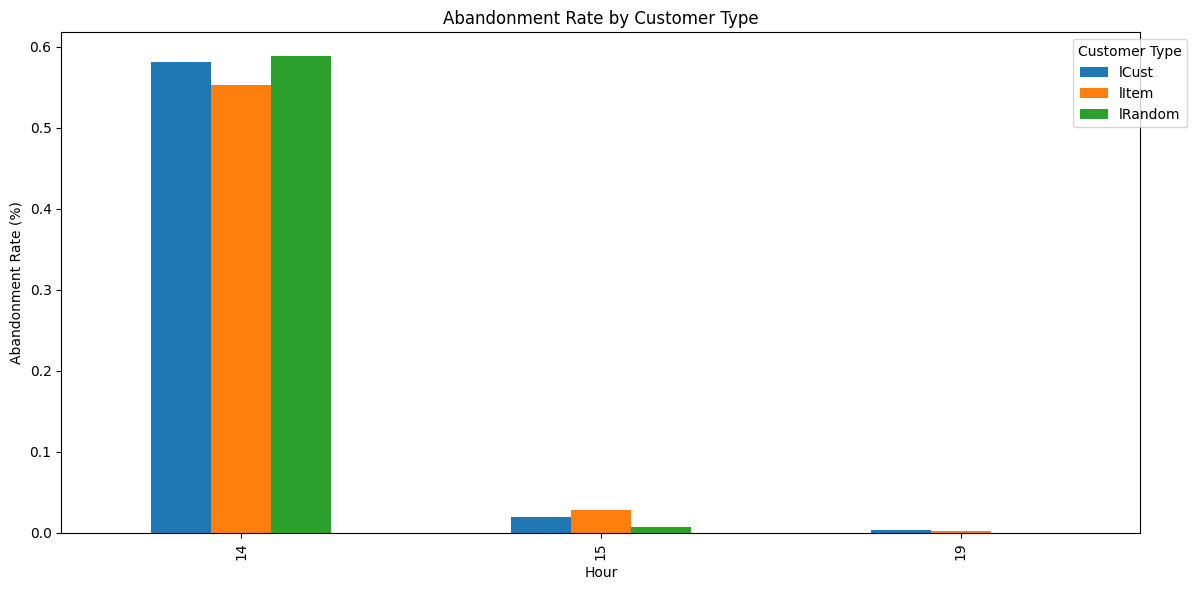


ITEM DISTRIBUTION DURING ABANDONMENT

      count   mean  median   max    std
hour                                   
14      586  43.48    55.0  85.0  25.93
15       36  40.78    50.0  74.0  23.35
19        8  59.25    65.0  75.0  19.17


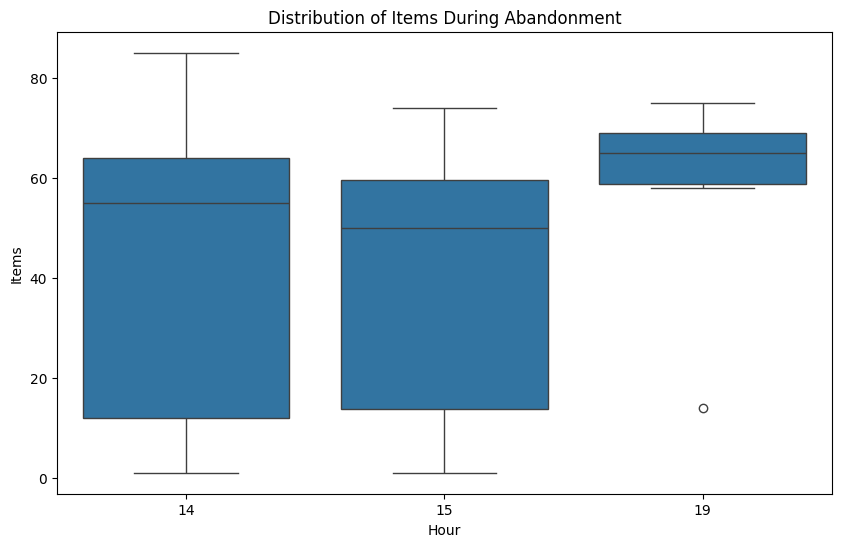

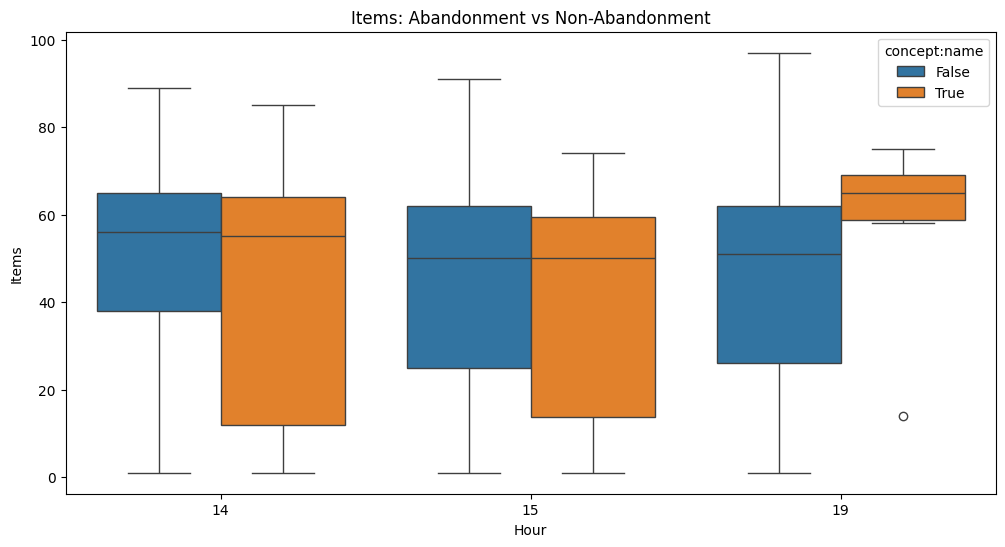


PAYMENT METHOD ANALYSIS

Unique payment methods:
[nan 'Pin' 'Cash']
p      Cash     Pin
hour               
14    12991   87595
15    24808  170850
16    45643  299555
17    48308  294003
18    45534  288636
19    57143  393269
20    50349  352116
21    25849  181422
22     1379    5881


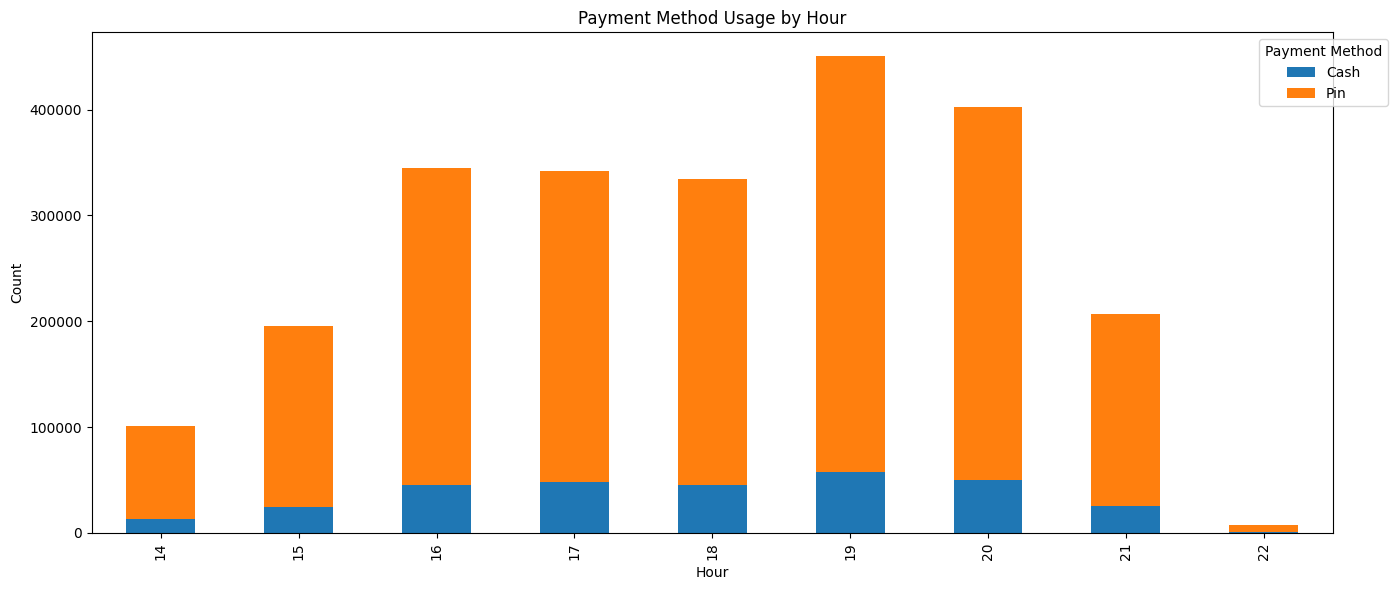


PAYMENT METHODS DURING ABANDONMENT

p     Cash  Pin
hour           
14     132  454
15       7   29
19       0    8


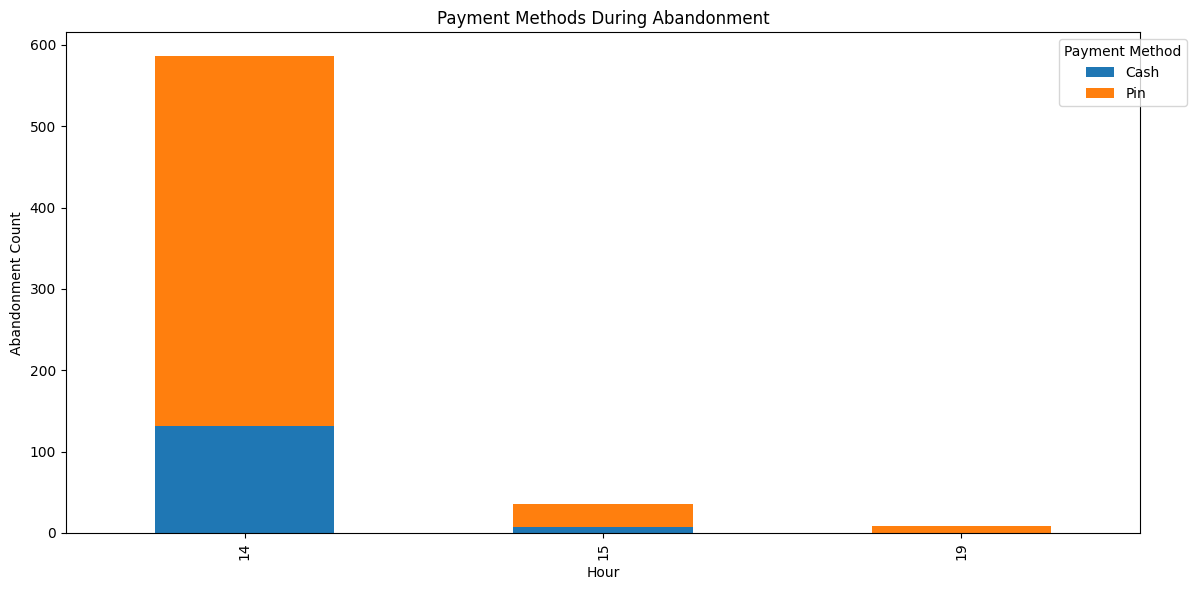

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# PREPARE DATA
# =========================================================

log_df_customer['time:timestamp'] = pd.to_datetime(
    log_df_customer['time:timestamp'],
    errors='coerce'
)

log_df_cashier['time:timestamp'] = pd.to_datetime(
    log_df_cashier['time:timestamp'],
    errors='coerce'
)

customer_df = log_df_customer.dropna(
    subset=['time:timestamp']
).copy()

cashier_df = log_df_cashier.dropna(
    subset=['time:timestamp']
).copy()

customer_df['hour'] = (
    customer_df['time:timestamp']
    .dt.hour
)

cashier_df['hour'] = (
    cashier_df['time:timestamp']
    .dt.hour
)

# =========================================================
# =========================================================
# 1. ABANDONMENT ANALYSIS
# =========================================================
# =========================================================

print("\n==============================")
print("ABANDONMENT ANALYSIS")
print("==============================\n")

# ---------------------------------------------------------
# ABANDONMENT EVENTS
# ---------------------------------------------------------

abandon_df = customer_df[
    customer_df['concept:name']
    == 'Abandon cart and leave'
].copy()

# Focus hours
target_hours = [14, 15, 19]

abandon_df = abandon_df[
    abandon_df['hour'].isin(target_hours)
]

# ---------------------------------------------------------
# CUSTOMER TYPES
# ---------------------------------------------------------

print("\nCUSTOMER TYPES DURING ABANDONMENT\n")

print(
    abandon_df['s']
    .value_counts()
)

customer_type_summary = (
    abandon_df.groupby(
        ['hour', 's']
    )
    .size()
    .unstack(fill_value=0)
)

print(customer_type_summary)

customer_type_summary.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title(
    "Customer Types During Abandonment"
)

plt.xlabel("Hour")

plt.ylabel("Abandonment Count")

plt.legend(
    title='Customer Type',
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()

plt.show()

# ---------------------------------------------------------
# ABANDONMENT RATE BY CUSTOMER TYPE
# MUCH STRONGER THAN RAW COUNTS
# ---------------------------------------------------------

all_customers = (
    customer_df[
        customer_df['hour'].isin(target_hours)
    ]
)

customer_totals = (
    all_customers.groupby(
        ['hour', 's']
    )
    .size()
)

abandon_totals = (
    abandon_df.groupby(
        ['hour', 's']
    )
    .size()
)

abandonment_rate = (
    abandon_totals
    /
    customer_totals
    * 100
)

abandonment_rate = (
    abandonment_rate
    .unstack(fill_value=0)
)

print("\nABANDONMENT RATE (%)\n")

print(
    abandonment_rate.round(2)
)

abandonment_rate.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    "Abandonment Rate by Customer Type"
)

plt.xlabel("Hour")

plt.ylabel("Abandonment Rate (%)")

plt.legend(
    title='Customer Type',
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()

plt.show()

# ---------------------------------------------------------
# ITEMS ANALYSIS
# ---------------------------------------------------------

print("\nITEM DISTRIBUTION DURING ABANDONMENT\n")

item_summary = (
    abandon_df.groupby('hour')
    ['items']
    .agg([
        'count',
        'mean',
        'median',
        'max',
        'std'
    ])
)

print(
    item_summary.round(2)
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=abandon_df,
    x='hour',
    y='items'
)

plt.title(
    "Distribution of Items During Abandonment"
)

plt.xlabel("Hour")

plt.ylabel("Items")

plt.show()

# ---------------------------------------------------------
# COMPARE WITH NORMAL CUSTOMERS
# VERY IMPORTANT BASELINE
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

sns.boxplot(
    data=customer_df[
        customer_df['hour'].isin(target_hours)
    ],
    x='hour',
    y='items',
    hue=customer_df[
        customer_df['hour'].isin(target_hours)
    ]['concept:name']
    == 'Abandon cart and leave'
)

plt.title(
    "Items: Abandonment vs Non-Abandonment"
)

plt.xlabel("Hour")

plt.ylabel("Items")

plt.show()


# =========================================================
# =========================================================
# 2. PAYMENT METHOD ANALYSIS
# =========================================================
# =========================================================

print("\n==============================")
print("PAYMENT METHOD ANALYSIS")
print("==============================\n")

print(
    "Unique payment methods:"
)

print(
    customer_df['p']
    .unique()
)

payment_hourly = (
    customer_df.groupby(
        ['hour', 'p']
    )
    .size()
    .unstack(fill_value=0)
)

print(payment_hourly)

payment_hourly.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title(
    "Payment Method Usage by Hour"
)

plt.xlabel("Hour")

plt.ylabel("Count")

plt.legend(
    title='Payment Method',
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()

plt.show()

# ---------------------------------------------------------
# PAYMENT METHOD DURING ABANDONMENT
# ---------------------------------------------------------

payment_abandon = (
    abandon_df.groupby(
        ['hour', 'p']
    )
    .size()
    .unstack(fill_value=0)
)

print("\nPAYMENT METHODS DURING ABANDONMENT\n")

print(payment_abandon)

payment_abandon.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title(
    "Payment Methods During Abandonment"
)

plt.xlabel("Hour")

plt.ylabel("Abandonment Count")

plt.legend(
    title='Payment Method',
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()

plt.show()

